# Radiologia multimodal con MedGemma 1.5 4B — Hugging Face Transformers

Este notebook ejecuta inferencia local sobre imagenes radiologicas con
`google/medgemma-1.5-4b-it` usando **Hugging Face Transformers** +
**BitsAndBytes** en una NVIDIA GeForce RTX 2060 (6 GB, Turing sm_75).

## Configuracion final funcional (validada)

- 4-bit NF4 + double quant (BitsAndBytes), compute dtype FP32 (default documentado).
- No cuantizados: BF16 (config del modelo).
- **Adaptacion minima para Turing**: torre de vision + proyector en **FP16**
  (Turing no tiene BF16 nativo; la SDPA de vision en BF16 se upcastea a FP32,
  ~1 GiB, y causa OOM. FP16 la reduce a ~537 MiB).
- Puente: la salida del proyector (FP16) se devuelve en BF16 al LLM.
- `max_new_tokens=2000` (valor de la model card oficial).
- Se elimina el bloque de razonamiento `thought` de MedGemma 1.5 antes de
  extraer las secciones.

Resultado observado (1 radiografia, prompt estructurado): reporte completo
con las 12 secciones, categoria y confianza extraidas; NaN/Inf = 0;
VRAM ~3.2 GiB.


In [1]:
# ============================================================
# CELDA 1: Verificación del entorno (Transformers 5.x)
# ============================================================

import os
import sys
import platform
from pathlib import Path

import torch

print("Python:", sys.version.split()[0])
print("Sistema operativo:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA compilada en PyTorch:", torch.version.cuda)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("VRAM total (GB):", round(props.total_memory / 1024**3, 2))
else:
    print("Dispositivo de ejecución: CPU")

import transformers
import accelerate
import bitsandbytes
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("BitsAndBytes:", bitsandbytes.__version__)


Python: 3.10.21
Sistema operativo: Linux-6.17.0-14-generic-x86_64-with-glibc2.39
PyTorch: 2.6.0+cu124
CUDA compilada en PyTorch: 12.4
CUDA disponible: True
GPU: NVIDIA GeForce RTX 2060
Compute capability: (7, 5)
VRAM total (GB): 5.6
Transformers: 5.16.1
Accelerate: 1.14.0
BitsAndBytes: 0.50.2


In [2]:
# ============================================================
# CELDA 2: Importación de librerías
# Explicación:
# Carga las bibliotecas necesarias para inferencia multimodal, visualización, métricas, persistencia, audio e interfaz gráfica.
# ============================================================

import os
import io
import re
import json
import time
import wave
import shutil
import tempfile
import contextlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageStat

import torch
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from dotenv import load_dotenv
from google import genai
from google.genai import types
import soundfile as sf
import gradio as gr


In [3]:
# ============================================================
# CELDA 3: Configuracion general del proyecto
# ============================================================

import os
from pathlib import Path

import numpy as np
import torch
from dotenv import load_dotenv
from huggingface_hub import get_token

DEFAULT_PROJECT_DIR = Path(
    "/home/judamo/Projects/Big-Data/Lab-3/medgemma-model"
).resolve()
PROJECT_DIR = Path(
    os.getenv("PROJECT_DIR", str(DEFAULT_PROJECT_DIR))
).expanduser().resolve()
load_dotenv(PROJECT_DIR / ".env")
PROJECT_DIR = Path(
    os.getenv("PROJECT_DIR", str(PROJECT_DIR))
).expanduser().resolve()

DATASET_DIR = Path(
    os.getenv("DATASET_DIR", str(PROJECT_DIR / "images_001"))
).expanduser().resolve()

OUTPUT_DIR = Path(
    os.getenv("OUTPUT_DIR", str(PROJECT_DIR / "outputs"))
).expanduser().resolve()

FIGURES_DIR = OUTPUT_DIR / "figuras"
REPORTS_DIR = OUTPUT_DIR / "reportes"
OFFLOAD_DIR = PROJECT_DIR / "offload_medgemma_1_5_4b"

for directory in [OUTPUT_DIR, FIGURES_DIR, REPORTS_DIR, OFFLOAD_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"No existe el dataset: {DATASET_DIR}")

MODEL_ID = "google/medgemma-1.5-4b-it"
MAX_EVAL_SAMPLES = 10
MAX_NEW_TOKENS = 384
SEED = 42

HF_TOKEN = os.getenv("HF_TOKEN") or get_token()
if not HF_TOKEN:
    raise EnvironmentError(
        "No se encontro un token de Hugging Face. Ejecuta: hf auth login"
    )

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Proyecto:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("Resultados:", OUTPUT_DIR)
print("Modelo:", MODEL_ID)
print("Token Hugging Face disponible:", bool(HF_TOKEN))


Proyecto: /home/judamo/Projects/Big-Data/Lab-3/medgemma-model
Dataset: /home/judamo/Projects/Big-Data/Lab-3/medgemma-model/images_001
Resultados: /home/judamo/Projects/Big-Data/Lab-3/medgemma-model/outputs
Modelo: google/medgemma-1.5-4b-it
Token Hugging Face disponible: True


In [4]:
# ============================================================
# CELDA 4: Configuracion opcional de Gemini TTS
# ============================================================

import os
from dotenv import load_dotenv

load_dotenv(PROJECT_DIR / ".env")

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GEMINI_TTS_MODEL = os.getenv(
    "GEMINI_TTS_MODEL",
    "gemini-2.5-flash-preview-tts",
)

print("Gemini TTS disponible:", bool(GEMINI_API_KEY))
print(
    "La clave de Gemini solo se usa para audio; "
    "la inferencia radiologica se ejecuta localmente con MedGemma."
)


Gemini TTS disponible: True
La clave de Gemini solo se usa para audio; la inferencia radiologica se ejecuta localmente con MedGemma.


# Estructura esperada del dataset

**Explicación:** La evaluación supervisada es opcional y depende de la presencia de etiquetas reales.

Estructura mínima:

```text
radiologia-model/
│
├── images_001/
│   └── images/
│       ├── 00000001_000.png
│       ├── 00000001_001.png
│       ├── 00000001_002.png
│       ├── 00000002_000.png
│       ├── 00000003_000.png
│       ├── 00000003_001.png
│       └── ...
│
├── outputs/
│   ├── figuras/
│   └── reportes/
│
└── .env

In [5]:
# ============================================================
# CELDA 5: Inventario completo del dataset con barra de progreso
# Explicación:
# Localiza automáticamente todas las imágenes radiográficas
# almacenadas dentro de DATASET_DIR. La busqueda recursiva
# incluye la subcarpeta interna "images".
#
# Durante el procesamiento se presenta una barra de progreso
# que indica porcentaje completado, número de imágenes
# procesadas, tiempo transcurrido y velocidad de lectura.
# ============================================================


# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

from pathlib import Path

import pandas as pd

from PIL import Image

from tqdm.notebook import tqdm

from IPython.display import display


# ============================================================
# 2. RUTA PRINCIPAL DEL DATASET
# ============================================================

# DATASET_DIR se configura en la CELDA 3 mediante .env o la ruta
# predeterminada PROJECT_DIR / "images_001".
DATASET_DIR = Path(DATASET_DIR).expanduser().resolve()


# ============================================================
# 3. EXTENSIONES DE IMAGEN PERMITIDAS
# ============================================================

VALID_EXTENSIONS = {

    ".png",

    ".jpg",

    ".jpeg",

    ".bmp",

    ".tif",

    ".tiff"

}


# ============================================================
# 4. VERIFICACIÓN DE LA RUTA
# ============================================================

print("=" * 80)

print("INVENTARIO DEL DATASET RADIOGRÁFICO")

print("=" * 80)

print()

print("Ruta principal del dataset:")

print(DATASET_DIR)

print()


if not DATASET_DIR.exists():

    raise FileNotFoundError(

        f"La carpeta del dataset no existe:\n\n{DATASET_DIR}"

    )


print("Estado de la ruta: CORRECTA")

print()


# ============================================================
# 5. IDENTIFICACIÓN DE CARPETAS DEL DATASET
# ============================================================

dataset_folders = sorted([

    folder

    for folder in DATASET_DIR.iterdir()

    if folder.is_dir()


])


print("=" * 80)

print("CARPETAS DEL DATASET DETECTADAS")

print("=" * 80)

print()


for folder in dataset_folders:

    print(folder.name)


print()

print(
    "Cantidad de carpetas detectadas:",
    len(dataset_folders)
)


# ============================================================
# 6. BÚSQUEDA RECURSIVA DE TODAS LAS IMÁGENES
# ============================================================

print()

print("=" * 80)

print("LOCALIZACIÓN DE IMÁGENES")

print("=" * 80)

print()

print("Buscando imágenes en todas las carpetas...")

print()


image_paths = sorted([

    path

    for path in DATASET_DIR.rglob("*")

    if path.is_file()

    and path.suffix.lower() in VALID_EXTENSIONS

])


# ============================================================
# 7. VALIDACIÓN DE IMÁGENES ENCONTRADAS
# ============================================================

if not image_paths:

    raise FileNotFoundError(

        f"No se encontraron imágenes compatibles en:\n\n{DATASET_DIR}"

    )


print(
    "Cantidad total de imágenes encontradas:",
    f"{len(image_paths):,}"
)


# ============================================================
# 8. CREACIÓN DE ESTRUCTURAS DE RESULTADOS
# ============================================================

records = []

errores = []


# ============================================================
# 9. PROCESAMIENTO DE LAS IMÁGENES
# ============================================================

print()

print("=" * 80)

print("ANÁLISIS DE LAS IMÁGENES")

print("=" * 80)

print()


for path in tqdm(

    image_paths,

    desc="Procesando radiografías",

    unit="imagen",

    dynamic_ncols=True

):

    try:

        # ----------------------------------------------------
        # Apertura de la imagen
        # ----------------------------------------------------

        with Image.open(path) as img:

            width, height = img.size

            mode = img.mode

            image_format = img.format


        # ----------------------------------------------------
        # Tamaño del archivo
        # ----------------------------------------------------

        file_size_kb = (

            path.stat().st_size / 1024

        )


        # ----------------------------------------------------
        # Identificación de la carpeta principal
        # ----------------------------------------------------

        relative_path = path.relative_to(DATASET_DIR)


        folder_group = (

            relative_path.parent.parts[0]

            if relative_path.parent != Path(".")

            else "raiz"

        )


        # ----------------------------------------------------
        # Registro de información
        # ----------------------------------------------------

        records.append({

            "folder": folder_group,

            "filename": path.name,

            "relative_path": str(relative_path),

            "path": str(path),

            "extension": path.suffix.lower(),

            "format": image_format,

            "width": width,

            "height": height,

            "resolution": f"{width} x {height}",

            "mode": mode,

            "file_size_kb": round(

                file_size_kb,

                2

            )

        })


    except Exception as exc:

        errores.append({

            "filename": path.name,

            "path": str(path),

            "error": str(exc)

        })


# ============================================================
# 10. CREACIÓN DEL DATAFRAME PRINCIPAL
# ============================================================

dataset_df = pd.DataFrame(

    records

)


if dataset_df.empty:

    raise ValueError(

        "No se pudo leer ninguna imagen valida del dataset."

    )


# ============================================================
# 11. DATAFRAME DE ERRORES
# ============================================================

errors_df = pd.DataFrame(

    errores

)


# ============================================================
# 12. RESUMEN GENERAL DEL DATASET
# ============================================================

print()

print("=" * 80)

print("PROCESAMIENTO FINALIZADO")

print("=" * 80)

print()


print(

    "Carpetas detectadas      :",

    f"{len(dataset_folders):,}"

)


print(

    "Archivos encontrados     :",

    f"{len(image_paths):,}"

)


print(

    "Imágenes válidas         :",

    f"{len(dataset_df):,}"

)


print(

    "Archivos con error       :",

    f"{len(errors_df):,}"

)


# ============================================================
# 13. INFORMACIÓN DE RESOLUCIÓN
# ============================================================

if not dataset_df.empty:

    print()

    print("-" * 80)

    print("CARACTERÍSTICAS DE LAS IMÁGENES")

    print("-" * 80)

    print()


    print(

        "Ancho mínimo            :",

        dataset_df["width"].min(),

        "px"

    )


    print(

        "Ancho máximo            :",

        dataset_df["width"].max(),

        "px"

    )


    print(

        "Alto mínimo             :",

        dataset_df["height"].min(),

        "px"

    )


    print(

        "Alto máximo             :",

        dataset_df["height"].max(),

        "px"

    )


    print(

        "Tamaño promedio         :",

        round(

            dataset_df["file_size_kb"].mean(),

            2

        ),

        "KB"

    )


    print(

        "Tamaño total            :",

        round(

            dataset_df["file_size_kb"].sum()

            / 1024

            / 1024,

            2

        ),

        "GB"

    )


# ============================================================
# 14. DISTRIBUCIÓN POR CARPETA
# ============================================================

if not dataset_df.empty:

    print()

    print("=" * 80)

    print("DISTRIBUCIÓN DE IMÁGENES POR CARPETA")

    print("=" * 80)

    print()


    folder_distribution = (

        dataset_df["folder"]

        .value_counts()

        .sort_index()

        .reset_index()

    )


    folder_distribution.columns = [

        "Carpeta",

        "Cantidad_imagenes"

    ]


    display(

        folder_distribution

    )


# ============================================================
# 15. VISUALIZACIÓN DEL INVENTARIO
# ============================================================

print()

print("=" * 80)

print("MUESTRA DEL INVENTARIO")

print("=" * 80)

print()


display(

    dataset_df.head(20)

)


# ============================================================
# 16. VISUALIZACIÓN DE ERRORES
# ============================================================

if not errors_df.empty:

    print()

    print("=" * 80)

    print("ARCHIVOS QUE NO PUDIERON SER PROCESADOS")

    print("=" * 80)

    print()


    display(

        errors_df.head(20)

    )


else:

    print()

    print(
        "No se detectaron errores durante la lectura de las imágenes."
    )

INVENTARIO DEL DATASET RADIOGRÁFICO

Ruta principal del dataset:
/home/judamo/Projects/Big-Data/Lab-3/medgemma-model/images_001

Estado de la ruta: CORRECTA

CARPETAS DEL DATASET DETECTADAS

images

Cantidad de carpetas detectadas: 1

LOCALIZACIÓN DE IMÁGENES

Buscando imágenes en todas las carpetas...

Cantidad total de imágenes encontradas: 4,999

ANÁLISIS DE LAS IMÁGENES



Procesando radiografías:   0%|          | 0/4999 [00:00<?, ?imagen/s]


PROCESAMIENTO FINALIZADO

Carpetas detectadas      : 1
Archivos encontrados     : 4,999
Imágenes válidas         : 4,999
Archivos con error       : 0

--------------------------------------------------------------------------------
CARACTERÍSTICAS DE LAS IMÁGENES
--------------------------------------------------------------------------------

Ancho mínimo            : 1024 px
Ancho máximo            : 1024 px
Alto mínimo             : 1024 px
Alto máximo             : 1024 px
Tamaño promedio         : 392.26 KB
Tamaño total            : 1.87 GB

DISTRIBUCIÓN DE IMÁGENES POR CARPETA



,Carpeta,Cantidad_imagenes
0,images,4999



MUESTRA DEL INVENTARIO



,folder,filename,relative_path,path,extension,format,width,height,resolution,mode,file_size_kb
0,images,00000001_000.png,images/00000001_000.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,446.46
1,images,00000001_001.png,images/00000001_001.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,434.23
2,images,00000001_002.png,images/00000001_002.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,343.53
3,images,00000002_000.png,images/00000002_000.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,392.90
4,images,00000003_000.png,images/00000003_000.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,439.45
5,images,00000003_001.png,images/00000003_001.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,374.78
6,images,00000003_002.png,images/00000003_002.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,335.23
7,images,00000003_003.png,images/00000003_003.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,445.90
8,images,00000003_004.png,images/00000003_004.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,362.49
9,images,00000003_005.png,images/00000003_005.png,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,.png,PNG,1024,1024,1024 x 1024,L,427.08



No se detectaron errores durante la lectura de las imágenes.


In [6]:
# ============================================================
# CELDA 6: Estadísticas descriptivas del dataset
# Explicación:
# Calcula estadísticas de dimensiones y tamaño de archivo para caracterizar las muestras disponibles.
# ============================================================

dataset_stats = dataset_df[
    ["width", "height", "file_size_kb"]
].describe().T.round(2)

dataset_stats["range"] = (
    dataset_stats["max"] - dataset_stats["min"]
).round(2)

display(dataset_stats)


,count,mean,std,min,25%,50%,75%,max,range
width,4999.0,1024.00,0.0,1024.00,1024.00,1024.00,1024.00,1024.00,0.00
height,4999.0,1024.00,0.0,1024.00,1024.00,1024.00,1024.00,1024.00,0.00
file_size_kb,4999.0,392.26,44.7,190.96,364.86,387.67,418.86,709.39,518.43


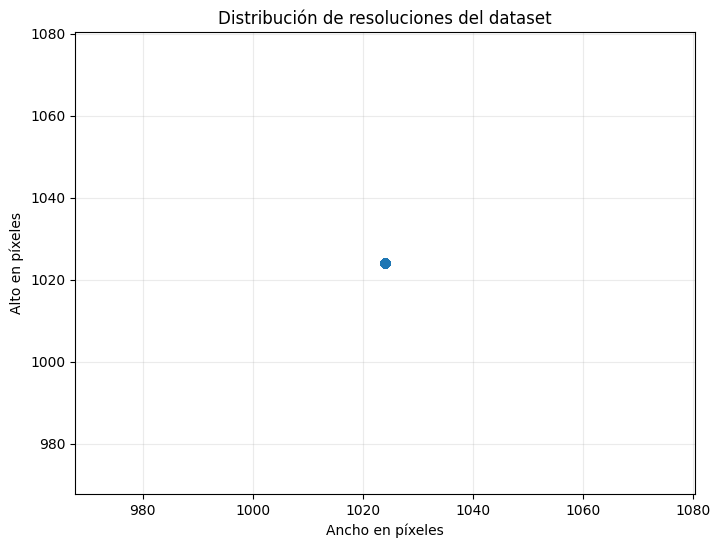

,Gráfica,Archivo,Interpretación
0,Distribución de resoluciones,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,La dispersión permite identificar homogeneidad...


In [7]:
# ============================================================
# CELDA 7: Gráfica de distribución de resoluciones
# Explicación:
# Genera, guarda y muestra una gráfica de dispersión con ancho y alto de las imágenes del dataset.
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dataset_df["width"], dataset_df["height"], alpha=0.7)
ax.set_title("Distribución de resoluciones del dataset")
ax.set_xlabel("Ancho en píxeles")
ax.set_ylabel("Alto en píxeles")
ax.grid(True, alpha=0.25)

resolution_plot = FIGURES_DIR / "01_distribucion_resoluciones.png"
fig.savefig(resolution_plot, dpi=160, bbox_inches="tight")
plt.show()

resolution_analysis = pd.DataFrame({
    "Gráfica": ["Distribución de resoluciones"],
    "Archivo": [str(resolution_plot)],
    "Interpretación": [
        "La dispersión permite identificar homogeneidad o variabilidad en las dimensiones de entrada. "
        "Una alta variabilidad puede justificar redimensionamiento o normalización antes de la inferencia."
    ]
})
display(resolution_analysis)


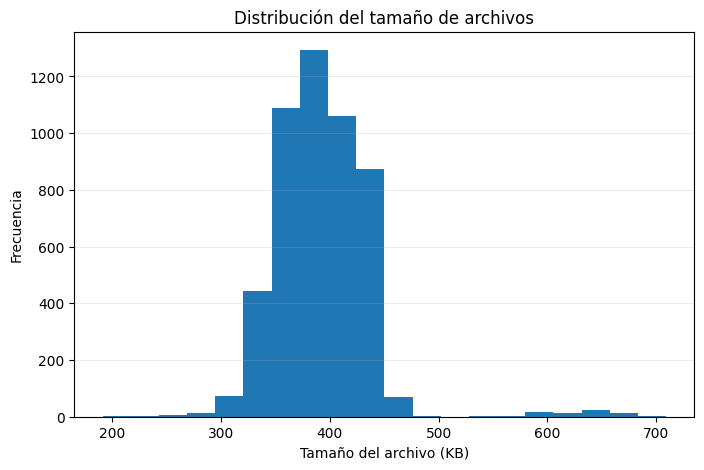

,Gráfica,Archivo,Interpretación
0,Distribución del tamaño de archivos,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,La distribución facilita la detección de archi...


In [8]:
# ============================================================
# CELDA 8: Gráfica del tamaño de archivos
# Explicación:
# Genera un histograma del tamaño en kilobytes, guarda la figura y presenta una tabla de interpretación.
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(dataset_df["file_size_kb"], bins=min(20, max(5, len(dataset_df))))
ax.set_title("Distribución del tamaño de archivos")
ax.set_xlabel("Tamaño del archivo (KB)")
ax.set_ylabel("Frecuencia")
ax.grid(True, axis="y", alpha=0.25)

size_plot = FIGURES_DIR / "02_distribucion_tamano_archivos.png"
fig.savefig(size_plot, dpi=160, bbox_inches="tight")
plt.show()

size_analysis = pd.DataFrame({
    "Gráfica": ["Distribución del tamaño de archivos"],
    "Archivo": [str(size_plot)],
    "Interpretación": [
        "La distribución facilita la detección de archivos atípicos por compresión, resolución o contenido. "
        "Valores extremos requieren revisión antes de atribuir diferencias al modelo."
    ]
})
display(size_analysis)


In [9]:
# ============================================================
# CELDA 9: Selección de muestras para evaluación
# Explicación:
# Selecciona un subconjunto reproducible del dataset para limitar el consumo de memoria y tiempo en una RTX 2060 / RTX 3050.
# ============================================================

sample_count = min(MAX_EVAL_SAMPLES, len(dataset_df))

sample_df = dataset_df.sample(
    n=sample_count,
    random_state=SEED
).reset_index(drop=True)

display(sample_df[["filename", "width", "height", "file_size_kb"]])


,filename,width,height,file_size_kb
0,00000013_046.png,1024,1024,438.83
1,00000632_013.png,1024,1024,440.81
2,00000744_006.png,1024,1024,437.79
3,00001333_001.png,1024,1024,413.72
4,00001315_006.png,1024,1024,347.02
5,00001257_000.png,1024,1024,430.98
6,00000032_043.png,1024,1024,337.57
7,00000181_008.png,1024,1024,345.14
8,00001252_000.png,1024,1024,338.20
9,00000289_007.png,1024,1024,434.75


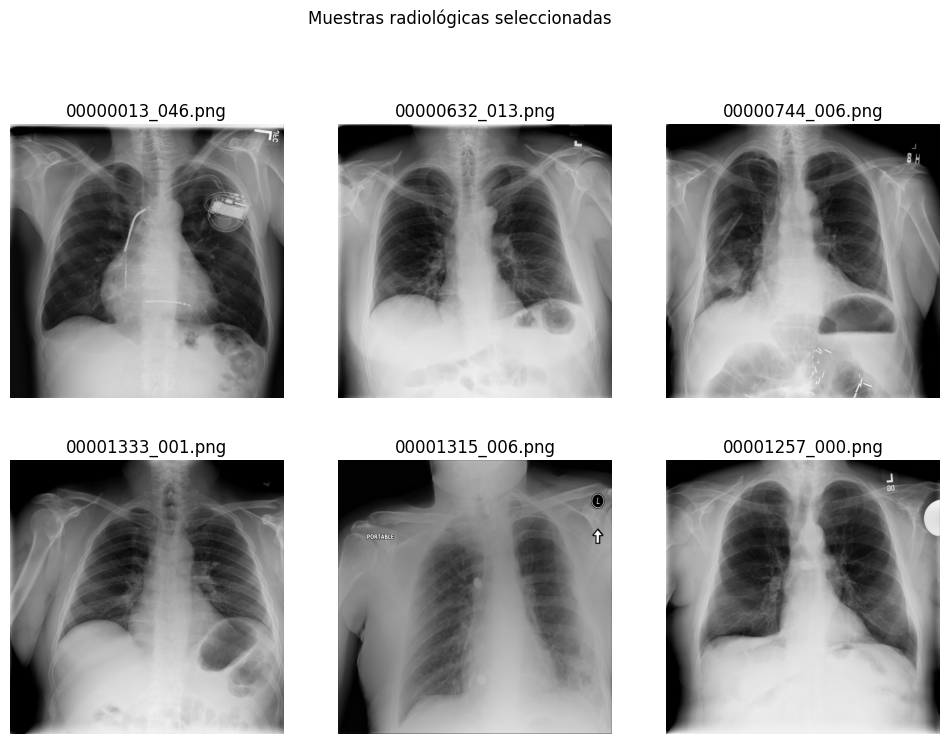

,Gráfica,Archivo,Interpretación
0,Muestras del dataset,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,La inspección visual permite verificar heterog...


In [10]:
# ============================================================
# CELDA 10: Visualización de muestras del dataset
# Explicación:
# Muestra una cuadrícula de imágenes seleccionadas y guarda la composición en el directorio de figuras.
# ============================================================

n_show = min(6, len(sample_df))
cols = 3
rows = int(np.ceil(n_show / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(-1)

for idx in range(len(axes)):
    ax = axes[idx]
    if idx < n_show:
        path = Path(sample_df.loc[idx, "path"])
        with Image.open(path) as img:
            ax.imshow(img.convert("RGB"))
        ax.set_title(sample_df.loc[idx, "filename"])
        ax.axis("off")
    else:
        ax.axis("off")

fig.suptitle("Muestras radiológicas seleccionadas", y=1.02)
sample_plot = FIGURES_DIR / "03_muestras_dataset.png"
fig.savefig(sample_plot, dpi=160, bbox_inches="tight")
plt.show()

sample_analysis = pd.DataFrame({
    "Gráfica": ["Muestras del dataset"],
    "Archivo": [str(sample_plot)],
    "Interpretación": [
        "La inspección visual permite verificar heterogeneidad, orientación, contraste y presencia de artefactos. "
        "La evaluación clínica no se deriva de esta inspección descriptiva."
    ]
})
display(sample_analysis)


In [11]:
# ============================================================
# CELDA 11: Métricas visuales básicas por imagen
# Explicación:
# Calcula brillo medio, contraste aproximado y relación de aspecto como indicadores descriptivos de calidad de entrada.
# ============================================================

quality_rows = []

for _, row in sample_df.iterrows():
    path = Path(row["path"])
    with Image.open(path) as img:
        gray = img.convert("L")
        stat = ImageStat.Stat(gray)
        mean_brightness = float(stat.mean[0])
        contrast_std = float(stat.stddev[0])
        aspect_ratio = img.width / img.height if img.height else np.nan

    quality_rows.append({
        "filename": row["filename"],
        "mean_brightness": round(mean_brightness, 3),
        "contrast_std": round(contrast_std, 3),
        "aspect_ratio": round(aspect_ratio, 4)
    })

quality_df = pd.DataFrame(quality_rows)
display(quality_df)


,filename,mean_brightness,contrast_std,aspect_ratio
0,00000013_046.png,109.951,61.521,1.0
1,00000632_013.png,138.628,66.385,1.0
2,00000744_006.png,124.085,65.053,1.0
3,00001333_001.png,116.303,67.928,1.0
4,00001315_006.png,119.635,54.042,1.0
5,00001257_000.png,136.908,71.069,1.0
6,00000032_043.png,112.236,60.416,1.0
7,00000181_008.png,122.301,46.329,1.0
8,00001252_000.png,148.189,64.927,1.0
9,00000289_007.png,132.974,69.656,1.0


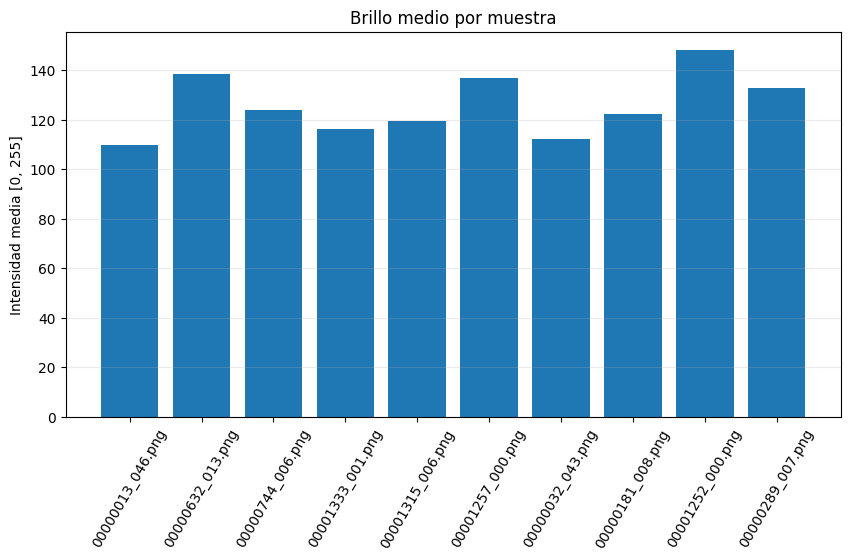

,Gráfica,Archivo,Interpretación
0,Brillo medio por muestra,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...,Diferencias amplias en intensidad media pueden...


In [12]:
# ============================================================
# CELDA 12: Gráfica de brillo por muestra
# Explicación:
# Compara el brillo medio de las imágenes seleccionadas, guarda la figura y presenta una interpretación tabular.
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(quality_df["filename"], quality_df["mean_brightness"])
ax.set_title("Brillo medio por muestra")
ax.set_ylabel("Intensidad media [0, 255]")
ax.tick_params(axis="x", rotation=60)
ax.grid(True, axis="y", alpha=0.25)

brightness_plot = FIGURES_DIR / "04_brillo_medio_muestras.png"
fig.savefig(brightness_plot, dpi=160, bbox_inches="tight")
plt.show()

brightness_analysis = pd.DataFrame({
    "Gráfica": ["Brillo medio por muestra"],
    "Archivo": [str(brightness_plot)],
    "Interpretación": [
        "Diferencias amplias en intensidad media pueden reflejar variaciones de exposición, posprocesamiento o formato. "
        "Estas diferencias pueden influir en la estabilidad de la interpretación multimodal."
    ]
})
display(brightness_analysis)


In [13]:
# ============================================================
# CELDA 13: Cuantizacion BitsAndBytes + adaptacion minima para Turing
# ============================================================

import torch
import bitsandbytes as bnb
from transformers import BitsAndBytesConfig

# El reporte estructurado necesita que el modelo razone y luego responda;
# la model card oficial usa max_new_tokens=2000. Se sobreescribe CELDA 3.
MAX_NEW_TOKENS = 3072

compute_dtype = torch.float32  # default documentado del compute 4-bit

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)


def adapt_vision_to_fp16(model):
    """Adaptacion minima para RTX 2060 (Turing, sin BF16 nativo).

    La torre de vision y el proyector pasan a FP16: en Turing la SDPA de
    vision en BF16 se upcastea a FP32 (~1 GiB) y causaba OOM; en FP16 se
    reduce (~537 MiB). El LLM se mantiene en BF16/4-bit con compute FP32
    (sin overflow/NaN). La salida del proyector se devuelve en BF16 para
    el LLM.
    """
    for p in model.model.vision_tower.parameters():
        if isinstance(p, bnb.nn.Params4bit):
            continue
        if p.dtype != torch.float16:
            p.data = p.data.to(torch.float16)
    for p in model.model.multi_modal_projector.parameters():
        if isinstance(p, bnb.nn.Params4bit):
            continue
        if p.dtype != torch.float16:
            p.data = p.data.to(torch.float16)
    orig_proj = model.model.multi_modal_projector.forward

    def proj_bf16(*a, **k):
        out = orig_proj(*a, **k)
        return out.to(torch.bfloat16) if isinstance(out, torch.Tensor) else out

    model.model.multi_modal_projector.forward = proj_bf16
    return model


def strip_thinking(text):
    """Quita el bloque de razonamiento 'thought' de MedGemma 1.5.

    El reporte estructurado real comienza en la primera linea de
    separacion '===='; el razonamiento termina justo antes.
    """
    text = (text or "").strip()
    if "thought" in text[:40] or text.startswith("===="):
        idx = text.find("====")
        if idx != -1:
            text = text[idx:]
    return text.strip()


print("Cuantizacion: NF4 4-bit + double quant")
print("Compute dtype:", compute_dtype)
print("No cuantizados: BF16 (config) excepto vision+proyector -> FP16")
print("MAX_NEW_TOKENS:", MAX_NEW_TOKENS)


Cuantizacion: NF4 4-bit + double quant
Compute dtype: torch.float32
No cuantizados: BF16 (config) excepto vision+proyector -> FP16
MAX_NEW_TOKENS: 3072


In [14]:
# ============================================================
# CELDA 14: Carga de MedGemma (Transformers 5.16.1)
# ============================================================

import time
from collections import Counter

import psutil
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

MODEL_LOADED = False


def gb(x):
    return round(x / 1024**3, 3)


def mem_gpu(tag):
    free, total = torch.cuda.mem_get_info()
    print(
        f"[GPU] {tag}: alloc={gb(torch.cuda.memory_allocated())}GiB "
        f"reserv={gb(torch.cuda.memory_reserved())}GiB "
        f"max={gb(torch.cuda.max_memory_allocated())}GiB "
        f"libre={gb(free)}GiB total={gb(total)}GiB"
    )


def mem_ram(tag):
    print(f"[RAM] {tag}: RSS={gb(psutil.Process().memory_info().rss)}GiB")


torch.cuda.empty_cache()
mem_gpu("inicio")
mem_ram("inicio")

model_load_start = time.perf_counter()
processor = AutoProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
mem_gpu("tras processor")

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN,
    quantization_config=quantization_config,
    device_map="auto",
    dtype="auto",
)
model = adapt_vision_to_fp16(model)
model.eval()
MODEL_LOADED = True
model_load_seconds = time.perf_counter() - model_load_start

hf_device_map = getattr(model, "hf_device_map", {})
counts = Counter(hf_device_map.values())
metas = [n for n, p in model.named_parameters() if p.is_meta]

print("Mapa de dispositivos (hf_device_map):",
      dict(counts) if counts else "(todo en un solo dispositivo)")
print("META tensors:", len(metas))
print("dtypes: embed =", model.model.language_model.embed_tokens.weight.dtype)
print("        vision =", next(model.model.vision_tower.parameters()).dtype)
print("        proyector =", model.model.multi_modal_projector.mm_input_projection_weight.dtype)
qproj = model.model.language_model.layers[0].self_attn.q_proj
print("        q_proj =", type(qproj).__name__, "| compute =", qproj.compute_dtype)
print("Tiempo de carga (s):", round(model_load_seconds, 2))
mem_gpu("tras carga")
mem_ram("tras carga")


[GPU] inicio: alloc=0.0GiB reserv=0.0GiB max=0.0GiB libre=4.781GiB total=5.6GiB
[RAM] inicio: RSS=0.954GiB
[GPU] tras processor: alloc=0.0GiB reserv=0.0GiB max=0.0GiB libre=4.782GiB total=5.6GiB


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Mapa de dispositivos (hf_device_map): (todo en un solo dispositivo)
META tensors: 0
dtypes: embed = torch.bfloat16
        vision = torch.float16
        proyector = torch.float16
        q_proj = Linear4bit | compute = torch.float32
Tiempo de carga (s): 5.35
[GPU] tras carga: alloc=3.009GiB reserv=3.074GiB max=3.018GiB libre=1.707GiB total=5.6GiB
[RAM] tras carga: RSS=1.313GiB


In [15]:
# ============================================================
# INFERENCIA MINIMA (Transformers) — 1 imagen, 64 tokens
# ============================================================

from PIL import Image

_img_dir = Path(DATASET_DIR) / "images"
_imgs = sorted(p for p in (_img_dir if _img_dir.exists() else Path(DATASET_DIR)).rglob("*")
               if p.suffix.lower() in {".png", ".jpg", ".jpeg"})
_img = _imgs[0]
with Image.open(_img) as im:
    _rgb = im.convert("RGB").copy()
_messages = [{"role": "user", "content": [
    {"type": "image", "image": _rgb},
    {"type": "text", "text": "Describe this X-ray."},
]}]
_inputs = processor.apply_chat_template(
    _messages, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt",
)
for _k in _inputs:
    _inputs[_k] = _inputs[_k].to("cuda")
_inputs["pixel_values"] = _inputs["pixel_values"].to(torch.float16)
_start = time.perf_counter()
with torch.inference_mode():
    _gen = model.generate(**_inputs, max_new_tokens=64, do_sample=False)
torch.cuda.synchronize()
_out = processor.decode(_gen[0][_inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
print("imagen:", _img.name)
print("tiempo:", round(time.perf_counter() - _start, 2), "s")
print("Salida:", _out[:300])
mem_gpu("tras generate")
mem_ram("tras generate")


imagen: 00000001_000.png
tiempo: 5.67 s
Salida: Based on the provided chest X-ray, here's a description:

*   **Heart Size:** The heart appears enlarged (cardiomegaly).
*   **Lung Fields:** The lung fields appear relatively clear, with no obvious signs of consolidation or significant abnormalities.
*   **Bones:** The bony
[GPU] tras generate: alloc=3.022GiB reserv=3.467GiB max=3.195GiB libre=1.237GiB total=5.6GiB
[RAM] tras generate: RSS=1.926GiB


## RESULTADO — Transformers + BitsAndBytes funcional

Configuracion que genera una inferencia valida en la RTX 2060 de 6 GB:

- 4-bit NF4 + double quant, compute FP32 (default documentado de BitsAndBytes).
- No cuantizados en BF16 (config del modelo); vision + proyector en FP16
  (adaptacion minima para Turing, evita el upcast FP32 de la SDPA de vision).
- `max_new_tokens=2000` (valor de la model card oficial).
- Bloque de razonamiento `thought` eliminado antes de la extraccion.

Observado:
- generate() OK (prompt "Describe this X-ray.", 64 tokens): ~5.8 s, VRAM ~3.2 GiB.
- Prompt estructurado completo: reporte con las 12 secciones, categoria y
  confianza extraidas; NaN/Inf = 0.
- META tensors: 0. Device map: todo en un dispositivo (GPU).


In [15]:
# ============================================================
# CELDA 15: Persistencia de la configuracion de MedGemma
# ============================================================

import json
from datetime import datetime

CONFIG_DIR = PROJECT_DIR / "configuracion"
CONFIG_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_FILE = CONFIG_DIR / "medgemma_1_5_4b_config.json"

medgemma_config = {
    "modelo": MODEL_ID,
    "proveedor": "Hugging Face",
    "tipo_ejecucion": "local",
    "gpu": torch.cuda.get_device_name(0),
    "cuantizacion": "NF4 4-bit",
    "dtype_calculo": str(compute_dtype),
    "max_new_tokens": MAX_NEW_TOKENS,
    "dataset": str(DATASET_DIR),
    "directorio_salida": str(OUTPUT_DIR),
    "semilla": SEED,
    "fecha_configuracion": datetime.now().isoformat(timespec="seconds"),
}

CONFIG_FILE.write_text(
    json.dumps(medgemma_config, indent=4, ensure_ascii=False),
    encoding="utf-8",
)

print("Configuracion almacenada en:", CONFIG_FILE)
print(json.dumps(medgemma_config, indent=4, ensure_ascii=False))


Configuracion almacenada en: /home/judamo/Projects/Big-Data/Lab-3/medgemma-model/configuracion/medgemma_1_5_4b_config.json
{
    "modelo": "google/medgemma-1.5-4b-it",
    "proveedor": "Hugging Face",
    "tipo_ejecucion": "local",
    "gpu": "NVIDIA GeForce RTX 2060",
    "cuantizacion": "NF4 4-bit",
    "dtype_calculo": "torch.float32",
    "max_new_tokens": 3072,
    "dataset": "/home/judamo/Projects/Big-Data/Lab-3/medgemma-model/images_001",
    "directorio_salida": "/home/judamo/Projects/Big-Data/Lab-3/medgemma-model/outputs",
    "semilla": 42,
    "fecha_configuracion": "2026-09-07T03:18:31"
}


In [16]:
# ============================================================
# CELDA 16: Definición del prompt radiológico para MedGemma
# Explicación:
# Define las instrucciones utilizadas por MedGemma para realizar
# el análisis estructurado de cada imagen radiográfica.
#
# La salida incluye:
#
# - Evaluación de calidad técnica.
# - Tipo y región anatómica.
# - Hallazgos visuales.
# - Localización de los hallazgos.
# - Impresión radiológica preliminar.
# - Clasificación general.
# - Nivel de confianza.
# - Limitaciones.
# - Recomendación.
#
# La estructura uniforme facilita el almacenamiento posterior
# de resultados en DataFrame y CSV, así como el cálculo de
# métricas cuando existan etiquetas reales.
# ============================================================


PROMPT_RADIOLOGIA = """
Analizar cuidadosamente la imagen radiológica proporcionada.

El análisis corresponde a un procedimiento experimental de
inteligencia artificial aplicado al procesamiento y análisis
de imágenes médicas.

Realizar una evaluación objetiva basada exclusivamente en la
información visual disponible en la imagen.

No asumir información clínica, antecedentes, síntomas, edad,
sexo ni resultados de otros estudios que no estén disponibles.

Generar la respuesta completamente en español y respetar
EXACTAMENTE la siguiente estructura:


============================================================
TIPO_ESTUDIO:
============================================================

Identificar, cuando sea posible, el tipo de estudio observado.

Ejemplos:

- Radiografía de tórax.
- Radiografía abdominal.
- Radiografía musculoesquelética.
- Otro.
- No determinado.


============================================================
REGION_ANATOMICA:
============================================================

Indicar la región anatómica principal visible en la imagen.

No inferir regiones que no sean claramente observables.


============================================================
CALIDAD_TECNICA:
============================================================

Evaluar brevemente la calidad técnica de la imagen considerando,
cuando sea posible:

- Resolución.
- Nitidez.
- Contraste.
- Brillo.
- Exposición.
- Posicionamiento.
- Rotación.
- Inspiración, cuando corresponda.
- Presencia de ruido.
- Presencia de artefactos.
- Visibilidad de las estructuras anatómicas.

Clasificar la calidad general como una de las siguientes:

ADECUADA
LIMITADA
NO_EVALUABLE


============================================================
HALLAZGOS:
============================================================

Describir objetivamente únicamente los hallazgos visibles.

Examinar sistemáticamente las estructuras anatómicas presentes.

Para una radiografía de tórax considerar, cuando sean visibles:

- Campos pulmonares.
- Hilios pulmonares.
- Pleuras.
- Senos costofrénicos.
- Diafragma.
- Silueta cardiomediastínica.
- Mediastino.
- Tráquea.
- Estructuras óseas.
- Tejidos blandos.
- Dispositivos médicos o elementos externos.

Para cada posible hallazgo describir, cuando sea posible:

- Tipo.
- Localización.
- Lateralidad.
- Distribución.
- Extensión.
- Características visuales.

No inventar hallazgos cuando la imagen no permita identificarlos.


============================================================
HALLAZGO_PRINCIPAL:
============================================================

Indicar el hallazgo visual considerado más relevante.

Cuando no exista un hallazgo evidente escribir:

Sin hallazgo radiográfico evidente.

Cuando la imagen no permita determinarlo escribir:

Indeterminado.


============================================================
LOCALIZACION:
============================================================

Indicar la localización anatómica del hallazgo principal.

Utilizar:

No aplica

cuando no exista un hallazgo evidente.

Utilizar:

Indeterminada

cuando la localización no pueda establecerse.


============================================================
IMPRESION:
============================================================

Generar una síntesis breve de los principales hallazgos
radiográficos observados.

La impresión debe derivarse exclusivamente de la imagen.

Evitar afirmaciones diagnósticas absolutas.


============================================================
CATEGORIA:
============================================================

Seleccionar EXACTAMENTE UNA de las siguientes categorías:

normal
abnormal
indeterminate

Criterios:

normal:
No se identifican alteraciones radiográficas evidentes en las
estructuras evaluables.

abnormal:
Existe al menos un hallazgo visual potencialmente anormal.

indeterminate:
La calidad, ambigüedad o información disponible no permite una
clasificación suficientemente fundamentada.

Escribir solamente una de las tres categorías indicadas.


============================================================
CONFIANZA:
============================================================

Asignar un valor entero entre 0 y 100 que represente el nivel
de confianza del análisis visual realizado.

Interpretación:

0-39   = confianza baja
40-69  = confianza moderada
70-89  = confianza alta
90-100 = confianza muy alta

El valor representa confianza del modelo y no probabilidad
clínica de enfermedad.


============================================================
JUSTIFICACION_CATEGORIA:
============================================================

Explicar brevemente qué evidencia visual condujo a seleccionar
la categoría anterior.


============================================================
LIMITACIONES:
============================================================

Describir las principales limitaciones del análisis.

Considerar:

- Calidad de imagen.
- Resolución.
- Proyección desconocida.
- Ausencia de información clínica.
- Superposición anatómica.
- Artefactos.
- Incertidumbre visual.
- Limitaciones propias del análisis automatizado.


============================================================
RECOMENDACION:
============================================================

Indicar que los resultados corresponden a un análisis
automatizado experimental.

Cuando existan hallazgos potencialmente relevantes, indicar la
necesidad de correlación con información clínica y valoración
por un profesional cualificado.

No presentar el resultado como sustituto de una interpretación
radiológica profesional.


============================================================
REGLAS GENERALES:
============================================================

1. Analizar exclusivamente la imagen proporcionada.

2. No inventar información clínica.

3. No afirmar patologías que no puedan sustentarse visualmente.

4. Diferenciar hallazgos observables de interpretaciones
   potenciales.

5. Expresar incertidumbre cuando corresponda.

6. Evitar afirmaciones absolutas.

7. Mantener terminología radiológica clara y consistente.

8. No utilizar información externa para modificar los hallazgos
   observados en la imagen.

9. Mantener exactamente los nombres de las secciones solicitadas.

10. En CATEGORIA escribir únicamente:
    normal, abnormal o indeterminate.

11. En CONFIANZA escribir únicamente un número entero entre
    0 y 100.

12. No omitir ninguna sección.
""".strip()


# ============================================================
# VERIFICACIÓN DEL PROMPT
# ============================================================

print("=" * 80)
print("PROMPT RADIOLÓGICO CONFIGURADO")
print("=" * 80)

print()

print(PROMPT_RADIOLOGIA)

print()

print("=" * 80)

print(
    "Cantidad de caracteres:",
    len(PROMPT_RADIOLOGIA)
)

print(
    "Cantidad aproximada de palabras:",
    len(PROMPT_RADIOLOGIA.split())
)

print("=" * 80)

PROMPT RADIOLÓGICO CONFIGURADO

Analizar cuidadosamente la imagen radiológica proporcionada.

El análisis corresponde a un procedimiento experimental de
inteligencia artificial aplicado al procesamiento y análisis
de imágenes médicas.

Realizar una evaluación objetiva basada exclusivamente en la
información visual disponible en la imagen.

No asumir información clínica, antecedentes, síntomas, edad,
sexo ni resultados de otros estudios que no estén disponibles.

Generar la respuesta completamente en español y respetar
EXACTAMENTE la siguiente estructura:


TIPO_ESTUDIO:

Identificar, cuando sea posible, el tipo de estudio observado.

Ejemplos:

- Radiografía de tórax.
- Radiografía abdominal.
- Radiografía musculoesquelética.
- Otro.
- No determinado.


REGION_ANATOMICA:

Indicar la región anatómica principal visible en la imagen.

No inferir regiones que no sean claramente observables.


CALIDAD_TECNICA:

Evaluar brevemente la calidad técnica de la imagen considerando,
cuando sea posi

In [17]:
# ============================================================
# CELDA 17: Inferencia y extraccion con MedGemma (Transformers)
# ============================================================

import re
import time
from pathlib import Path

import torch
from PIL import Image


REQUIRED_REPORT_SECTIONS = (
    "TIPO_ESTUDIO",
    "REGION_ANATOMICA",
    "CALIDAD_TECNICA",
    "HALLAZGOS",
    "HALLAZGO_PRINCIPAL",
    "LOCALIZACION",
    "IMPRESION",
    "CATEGORIA",
    "CONFIANZA",
    "JUSTIFICACION_CATEGORIA",
    "LIMITACIONES",
    "RECOMENDACION",
)


def extract_section(text, section_name):
    """Extrae una seccion del reporte estructurado."""
    headings = (
        "TIPO_ESTUDIO|REGION_ANATOMICA|CALIDAD_TECNICA|HALLAZGOS|"
        "HALLAZGO_PRINCIPAL|LOCALIZACION|IMPRESION|CATEGORIA|CONFIANZA|"
        "JUSTIFICACION_CATEGORIA|LIMITACIONES|RECOMENDACION"
    )
    pattern = (
        rf"(?:^|\n)\s*(?:=+\s*)?(?:#+\s*)?"
        rf"{re.escape(section_name)}\s*:\s*(?:=+\s*)?(.*?)"
    )
    pattern += (
        rf"(?=\n\s*(?:=+\s*)?(?:#+\s*)?"
        rf"(?:{headings})\s*:|\Z)"
    )
    match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
    if not match:
        return ""
    content = re.sub(r"^\s*=+\s*|\s*=+\s*$", "", match.group(1))
    return content.strip()


def extract_category(text):
    """Extrae una de las tres categorias permitidas."""
    section = extract_section(text, "CATEGORIA")
    match = re.search(
        r"\b(normal|abnormal|indeterminate)\b",
        section,
        flags=re.IGNORECASE,
    )
    return match.group(1).lower() if match else "indeterminate"


def extract_confidence(text):
    """Extrae la confianza declarada por el modelo entre 0 y 100."""
    section = extract_section(text, "CONFIANZA")
    match = re.search(r"\b(100|\d{1,2})\b", section)
    return int(match.group(1)) if match else None


def infer_radiology(image_path):
    """Analiza una imagen con MedGemma (Transformers) y devuelve campos."""
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"No se encontro la imagen: {image_path}")

    with Image.open(image_path) as image:
        rgb_image = image.convert("RGB").copy()

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": rgb_image},
                {"type": "text", "text": PROMPT_RADIOLOGIA},
            ],
        }
    ]

    start = time.perf_counter()
    try:
        inputs = processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )
        for _k in inputs:
            inputs[_k] = inputs[_k].to("cuda")
        inputs["pixel_values"] = inputs["pixel_values"].to(torch.float16)
        input_length = inputs["input_ids"].shape[-1]

        gen_start = time.perf_counter()
        print(
            f"    Generando hasta {MAX_NEW_TOKENS} tokens...",
            flush=True,
        )
        with torch.inference_mode():
            generated = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
            )
        torch.cuda.synchronize()
        generated_text = strip_thinking(
            processor.decode(generated[0][input_length:], skip_special_tokens=True)
        )
        latency = time.perf_counter() - start
        gen_seconds = time.perf_counter() - gen_start
        peak_vram_gb = torch.cuda.max_memory_allocated() / 1024**3
        print(
            f"    Generacion finalizada: {gen_seconds:.1f} s",
            flush=True,
        )
    except Exception as exc:
        return {
            "filename": image_path.name,
            "path": str(image_path),
            "status": "error",
            "error": str(exc),
            "report": "",
            "category": "indeterminate",
            "confidence": None,
            "latency_seconds": round(time.perf_counter() - start, 3),
            "peak_vram_gb": None,
            "word_count": 0,
            "char_count": 0,
        }

    missing_sections = [
        section for section in REQUIRED_REPORT_SECTIONS
        if not extract_section(generated_text, section)
    ]
    parse_error = not generated_text or bool(missing_sections)

    # Reparacion: si faltan secciones, pedir la continuacion en una
    # segunda generacion corta (solo texto, sin imagen).
    repair_attempts = 0
    while missing_sections and repair_attempts < 2:
        repair_attempts += 1
        missing_text = ", ".join(missing_sections)
        repair_prompt = (
            "El reporte radiologico estructurado anterior quedo incompleto.\n"
            "\n"
            "--- INICIO DEL REPORTE PARCIAL ---\n"
            f"{generated_text[-2000:]}\n"
            "--- FIN DEL REPORTE PARCIAL ---\n"
            "\n"
            "Continua redactando exactamente desde donde quedo y completa "
            "EXCLUSIVAMENTE las secciones faltantes, en el mismo formato "
            "estricto (nombre de seccion en mayusculas seguido de ':').\n"
            "Secciones que faltan:\n"
            f"{missing_text}"
        )
        repair_messages = [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": repair_prompt},
                ],
            }
        ]
        repair_inputs = processor.apply_chat_template(
            repair_messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )
        for _k in repair_inputs:
            repair_inputs[_k] = repair_inputs[_k].to("cuda")
        with torch.inference_mode():
            repair_ids = model.generate(
                **repair_inputs,
                max_new_tokens=1536,
                do_sample=False,
            )
        torch.cuda.synchronize()
        repair_text = strip_thinking(
            processor.decode(
                repair_ids[0][repair_inputs["input_ids"].shape[-1]:],
                skip_special_tokens=True,
            )
        )
        generated_text = f"{generated_text}\n{repair_text}".strip()
        missing_sections = [
            section for section in REQUIRED_REPORT_SECTIONS
            if not extract_section(generated_text, section)
        ]
        parse_error = not generated_text or bool(missing_sections)
    fields = {
        "tipo_estudio": "TIPO_ESTUDIO",
        "region_anatomica": "REGION_ANATOMICA",
        "calidad_tecnica": "CALIDAD_TECNICA",
        "hallazgos": "HALLAZGOS",
        "hallazgo_principal": "HALLAZGO_PRINCIPAL",
        "localizacion": "LOCALIZACION",
        "impresion": "IMPRESION",
        "justificacion_categoria": "JUSTIFICACION_CATEGORIA",
        "limitaciones": "LIMITACIONES",
        "recomendacion": "RECOMENDACION",
    }

    result = {
        "filename": image_path.name,
        "path": str(image_path),
        "status": "parse_error" if parse_error else "success",
        "error": (
            "Faltan secciones requeridas: " + ", ".join(missing_sections)
            if parse_error else ""
        ),
        "report": generated_text,
        "category": extract_category(generated_text),
        "confidence": extract_confidence(generated_text),
        "latency_seconds": round(latency, 3),
        "peak_vram_gb": round(peak_vram_gb, 3),
        "word_count": len(generated_text.split()),
        "char_count": len(generated_text),
    }
    result.update(
        {key: extract_section(generated_text, heading) for key, heading in fields.items()}
    )
    return result


In [19]:
# ============================================================
# CELDA 18: Inferencia sobre 10 imágenes del dataset con MedGemma local
# Explicación:
# Selecciona exactamente 10 imágenes del dataset y ejecuta
# MedGemma sobre cada una.
#
# Para cada radiografía se registran:
#
# - Categoría predicha.
# - Nivel de confianza.
# - Tipo de estudio.
# - Región anatómica.
# - Calidad técnica.
# - Hallazgo principal.
# - Localización.
# - Impresión.
# - Latencia de inferencia.
# - Longitud del reporte.
# - Estado del procesamiento.
#
# La selección utiliza una semilla fija para garantizar que
# las mismas 10 imágenes puedan reproducirse posteriormente.
#
# La inferencia se realiza localmente con CUDA y cuantizacion de 4 bits.
# La VRAM maxima se registra para cada muestra.
# ============================================================

import numpy as np
import pandas as pd

from tqdm.notebook import tqdm
from IPython.display import display


# ============================================================
# 1. CONFIGURACIÓN DEL NÚMERO DE IMÁGENES
# ============================================================

NUMERO_IMAGENES_ANALISIS = 10

RANDOM_STATE = 42


# ============================================================
# 2. VALIDACIÓN DEL DATASET
# ============================================================

if "dataset_df" not in globals():

    raise NameError(
        "dataset_df no se encuentra definido. "
        "Debe ejecutarse previamente la celda de carga del dataset."
    )


if dataset_df.empty:

    raise ValueError(
        "dataset_df se encuentra vacío."
    )


if "path" not in dataset_df.columns:

    raise KeyError(
        "La columna 'path' no existe en dataset_df."
    )


if "filename" not in dataset_df.columns:

    raise KeyError(
        "La columna 'filename' no existe en dataset_df."
    )


# ============================================================
# 3. DETERMINACIÓN DEL NÚMERO REAL DE MUESTRAS
# ============================================================

numero_muestras = min(
    NUMERO_IMAGENES_ANALISIS,
    len(dataset_df)
)


# ============================================================
# 4. SELECCIÓN ALEATORIA DE 10 RADIOGRAFÍAS
# ============================================================

sample_df = (
    dataset_df
    .sample(
        n=numero_muestras,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("SELECCIÓN DE IMÁGENES PARA MEDGEMMA")
print("=" * 80)

print(
    "Total de imágenes disponibles:",
    len(dataset_df)
)

print(
    "Imágenes seleccionadas:",
    len(sample_df)
)

print(
    "Semilla de selección:",
    RANDOM_STATE
)

print("=" * 80)


# ============================================================
# 5. VISUALIZACIÓN DE LAS 10 IMÁGENES SELECCIONADAS
# ============================================================

columnas_muestra = [
    column
    for column in [
        "filename",
        "folder",
        "resolution",
        "path"
    ]
    if column in sample_df.columns
]


display(
    sample_df[
        columnas_muestra
    ]
)


# ============================================================
# 6. ESTRUCTURA PARA ALMACENAR RESULTADOS
# ============================================================

evaluation_rows = []


# ============================================================
# 7. PROCESAMIENTO DE LAS 10 IMÁGENES
# ============================================================

for position, row in tqdm(
    sample_df.iterrows(),
    total=len(sample_df),
    desc="Analizando radiografías con MedGemma",
    unit="imagen",
    dynamic_ncols=True
):

    try:

        # ----------------------------------------------------
        # Información de seguimiento
        # ----------------------------------------------------

        print(
            f"\nProcesando imagen "
            f"{position + 1}/{len(sample_df)}: "
            f"{row['filename']}"
        )


        # ----------------------------------------------------
        # Inferencia mediante MedGemma local
        # ----------------------------------------------------

        result = infer_radiology(
            row["path"]
        )

        print(
            f"    Estado: {result.get('status')} | "
            f"Latencia: {result.get('latency_seconds')} s | "
            f"VRAM pico: {result.get('peak_vram_gb')} GB"
        )


        # ----------------------------------------------------
        # Registro del resultado
        # ----------------------------------------------------

        evaluation_rows.append({

            "sample_number":
                position + 1,

            "filename":
                row["filename"],

            "path":
                row["path"],

            "status":
                result.get(
                    "status",
                    "success"
                ),

            "category_pred":
                result.get(
                    "category",
                    "indeterminate"
                ),

            "confidence":
                result.get(
                    "confidence",
                    np.nan
                ),

            "tipo_estudio":
                result.get(
                    "tipo_estudio",
                    ""
                ),

            "region_anatomica":
                result.get(
                    "region_anatomica",
                    ""
                ),

            "calidad_tecnica":
                result.get(
                    "calidad_tecnica",
                    ""
                ),

            "hallazgos":
                result.get(
                    "hallazgos",
                    ""
                ),

            "hallazgo_principal":
                result.get(
                    "hallazgo_principal",
                    ""
                ),

            "localizacion":
                result.get(
                    "localizacion",
                    ""
                ),

            "impresion":
                result.get(
                    "impresion",
                    ""
                ),

            "justificacion_categoria":
                result.get(
                    "justificacion_categoria",
                    ""
                ),

            "limitaciones":
                result.get(
                    "limitaciones",
                    ""
                ),

            "recomendacion":
                result.get(
                    "recomendacion",
                    ""
                ),

            "peak_vram_gb":
                result.get("peak_vram_gb", np.nan),

            "latency_seconds":
                round(
                    result.get(
                        "latency_seconds",
                        np.nan
                    ),
                    3
                ),

            "word_count":
                result.get(
                    "word_count",
                    np.nan
                ),

            "char_count":
                result.get(
                    "char_count",
                    np.nan
                ),

            "report":
                result.get(
                    "report",
                    ""
                ),

            "error":
                result.get(
                    "error",
                    ""
                )

        })


    except Exception as exc:

        # ----------------------------------------------------
        # Registro controlado de errores
        # ----------------------------------------------------

        evaluation_rows.append({

            "sample_number":
                position + 1,

            "filename":
                row["filename"],

            "path":
                row["path"],

            "status":
                "error",

            "category_pred":
                "error",

            "confidence":
                np.nan,

            "tipo_estudio":
                "",

            "region_anatomica":
                "",

            "calidad_tecnica":
                "",

            "hallazgos":
                "",

            "hallazgo_principal":
                "",

            "localizacion":
                "",

            "impresion":
                "",

            "justificacion_categoria":
                "",

            "limitaciones":
                "",

            "recomendacion":
                "",

            "latency_seconds":
                np.nan,

            "peak_vram_gb":
                np.nan,

            "word_count":
                np.nan,

            "char_count":
                np.nan,

            "report":
                "",

            "error":
                str(exc)

        })


# ============================================================
# 8. CREACIÓN DEL DATAFRAME DE RESULTADOS
# ============================================================

evaluation_df = pd.DataFrame(
    evaluation_rows
)

EVALUATION_CSV = REPORTS_DIR / "evaluacion_medgemma.csv"
EVALUATION_JSON = REPORTS_DIR / "evaluacion_medgemma.json"
evaluation_df.to_csv(EVALUATION_CSV, index=False)
evaluation_df.to_json(
    EVALUATION_JSON, orient="records", force_ascii=False, indent=2
)


# ============================================================
# 9. RESUMEN DE PROCESAMIENTO
# ============================================================

total_samples = len(
    evaluation_df
)


successful_samples = (
    evaluation_df[
        "status"
    ]
    .eq("success")
    .sum()
)


error_samples = (
    evaluation_df[
        "status"
    ]
    .ne("success")
    .sum()
)


print()

print("=" * 80)

print(
    "INFERENCIA MEDIANTE MEDGEMMA FINALIZADA"
)

print("=" * 80)

print(
    "Modelo:",
    MODEL_ID
)

print(
    "Imágenes programadas:",
    numero_muestras
)

print(
    "Imágenes procesadas:",
    total_samples
)

print(
    "Procesamientos exitosos:",
    successful_samples
)

print(
    "Procesamientos con error:",
    error_samples
)


# ============================================================
# 10. MÉTRICAS OPERATIVAS PRELIMINARES
# ============================================================

if successful_samples > 0:

    successful_df = evaluation_df[
        evaluation_df[
            "status"
        ] == "success"
    ].copy()


    print()

    print(
        "Latencia promedio:",
        round(
            successful_df[
                "latency_seconds"
            ].mean(),
            3
        ),
        "segundos"
    )


    print(
        "Latencia mínima:",
        round(
            successful_df[
                "latency_seconds"
            ].min(),
            3
        ),
        "segundos"
    )


    print(
        "Latencia máxima:",
        round(
            successful_df[
                "latency_seconds"
            ].max(),
            3
        ),
        "segundos"
    )


    print(
        "Latencia mediana:",
        round(
            successful_df[
                "latency_seconds"
            ].median(),
            3
        ),
        "segundos"
    )


    print(
        "Palabras promedio por reporte:",
        round(
            successful_df[
                "word_count"
            ].mean(),
            2
        )
    )


    if successful_df[
        "confidence"
    ].notna().any():

        print(
            "Confianza promedio:",
            round(
                successful_df[
                    "confidence"
                ].mean(),
                2
            )
        )


# ============================================================
# 11. DISTRIBUCIÓN DE CATEGORÍAS
# ============================================================

if successful_samples > 0:

    print()

    print("=" * 80)

    print(
        "DISTRIBUCIÓN DE CATEGORÍAS"
    )

    print("=" * 80)


    category_distribution = (
        successful_df[
            "category_pred"
        ]
        .value_counts(
            dropna=False
        )
        .rename_axis(
            "categoria"
        )
        .reset_index(
            name="cantidad"
        )
    )


    display(
        category_distribution
    )


# ============================================================
# 12. VISUALIZACIÓN DE RESULTADOS
# ============================================================

columns_to_display = [

    "sample_number",

    "filename",

    "status",

    "category_pred",

    "confidence",

    "tipo_estudio",

    "region_anatomica",

    "hallazgos",

    "hallazgo_principal",

    "localizacion",

    "latency_seconds",

    "peak_vram_gb",

    "word_count",

    "char_count",

    "error"

]


print()

print("=" * 80)

print(
    "RESULTADOS DE LAS 10 RADIOGRAFÍAS"
)

print("=" * 80)


display(

    evaluation_df[
        columns_to_display
    ]

)

SELECCIÓN DE IMÁGENES PARA MEDGEMMA
Total de imágenes disponibles: 4999
Imágenes seleccionadas: 10
Semilla de selección: 42


,filename,folder,resolution,path
0,00000013_046.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
1,00000632_013.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
2,00000744_006.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
3,00001333_001.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
4,00001315_006.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
5,00001257_000.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
6,00000032_043.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
7,00000181_008.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
8,00001252_000.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...
9,00000289_007.png,images,1024 x 1024,/home/judamo/Projects/Big-Data/Lab-3/medgemma-...


Analizando radiografías con MedGemma:   0%|          | 0/10 [00:00<?, ?imagen/s]


Procesando imagen 1/10: 00000013_046.png
    Generando hasta 2000 tokens...
    Generacion finalizada: 137.3 s
    Estado: parse_error | Latencia: 137.352 s | VRAM pico: 3.504 GB

Procesando imagen 2/10: 00000632_013.png
    Generando hasta 2000 tokens...
    Generacion finalizada: 142.7 s
    Estado: success | Latencia: 142.717 s | VRAM pico: 3.504 GB

Procesando imagen 3/10: 00000744_006.png
    Generando hasta 2000 tokens...
    Generacion finalizada: 131.3 s
    Estado: success | Latencia: 131.297 s | VRAM pico: 3.504 GB

Procesando imagen 4/10: 00001333_001.png
    Generando hasta 2000 tokens...
    Generacion finalizada: 151.6 s
    Estado: parse_error | Latencia: 151.572 s | VRAM pico: 3.504 GB

Procesando imagen 5/10: 00001315_006.png
    Generando hasta 2000 tokens...
    Generacion finalizada: 152.2 s
    Estado: parse_error | Latencia: 152.207 s | VRAM pico: 3.504 GB

Procesando imagen 6/10: 00001257_000.png
    Generando hasta 2000 tokens...
    Generacion finalizada: 145.

,categoria,cantidad
0,abnormal,3



RESULTADOS DE LAS 10 RADIOGRAFÍAS


,sample_number,filename,status,category_pred,confidence,tipo_estudio,region_anatomica,hallazgos,hallazgo_principal,localizacion,latency_seconds,peak_vram_gb,word_count,char_count,error
0,1,00000013_046.png,parse_error,indeterminate,NaN,Radiografía de tórax.,Tórax.,"* Campos pulmonares: Generalmente claros, co...",Blanqueamiento del ángulo costofrénico derecho...,Ángulo costofrénico derecho y campo pulmonar i...,137.352,3.504,165,2122,"Faltan secciones requeridas: CATEGORIA, CONFIA..."
1,2,00000632_013.png,success,abnormal,75.0,Radiografía de tórax.,Tórax.,Opacidad en el campo pulmonar inferior derecho.,Opacidad en el campo pulmonar inferior derecho.,Campo pulmonar inferior derecho.,142.717,3.504,180,2787,
2,3,00000744_006.png,success,abnormal,75.0,Radiografía de tórax.,Tórax.,* Opacidad/Consolidación en el lóbulo inferi...,Opacidad/Consolidación en el lóbulo inferior d...,Lóbulo inferior derecho.,131.297,3.504,178,2801,
3,4,00001333_001.png,parse_error,normal,95.0,Radiografía de tórax.,Tórax.,No se identifican alteraciones radiográficas e...,Sin hallazgo radiográfico evidente.,No aplica.,151.572,3.504,78,1778,"Faltan secciones requeridas: LIMITACIONES, REC..."
4,5,00001315_006.png,parse_error,indeterminate,NaN,Radiografía de tórax.,Pulmones y corazón.,Campos pulmonares: Se observa una cierta opaci...,,,152.207,3.504,126,1421,Faltan secciones requeridas: HALLAZGO_PRINCIPA...
5,6,00001257_000.png,parse_error,normal,95.0,Radiografía de tórax.,Tórax.,Campos pulmonares sin opacidades evidentes. Hi...,No hallazgo radiográfico evidente.,No aplica.,145.617,3.504,100,1922,"Faltan secciones requeridas: LIMITACIONES, REC..."
6,7,00000032_043.png,parse_error,indeterminate,NaN,Radiografía de tórax.,"Campos pulmonares, Hilios pulmonares, Pleuras,...",* Campos pulmonares: Opacidades significativ...,Opacidad significativa en el hemitorax izquier...,Hemitorax izquierdo.,150.828,3.504,209,2307,"Faltan secciones requeridas: IMPRESION, CATEGO..."
7,8,00000181_008.png,parse_error,indeterminate,NaN,Radiografía de tórax.,"Campos pulmonares, pleuras, senos costofrénico...",* Campos pulmonares: Se observan opacidades ...,Opacidades difusas y parcheadas en ambos campo...,* Hallazgo principal: Campos pulmonares.\n* ...,140.897,3.504,218,2489,"Faltan secciones requeridas: CATEGORIA, CONFIA..."
8,9,00001252_000.png,success,abnormal,85.0,Radiografía de tórax.,Tórax.,Se observa un dispositivo (posiblemente un mar...,Un dispositivo (posiblemente un marcapasos) es...,"Hemitorax derecho, región superior.",139.117,3.504,179,2646,
9,10,00000289_007.png,parse_error,normal,95.0,Radiografía de tórax.,Tórax.,No se identifican alteraciones radiográficas e...,Sin hallazgo radiográfico evidente.,No aplica.,140.131,3.504,129,2220,Faltan secciones requeridas: RECOMENDACION


In [20]:
# ============================================================
# CELDA NUEVA: Re-extracción de campos desde los reportes
# Explicación:
# Repuebla los campos estructurados (categoría, confianza y
# secciones) directamente desde la columna "report" ya generada
# por MedGemma, sin volver a ejecutar el modelo.
#
# Requisito: ejecutar primero la CELDA 17 (funciones de
# extracción corregidas) y tener evaluation_df generado.
# ============================================================

if "evaluation_df" not in globals():

    raise NameError(
        "evaluation_df no está definido. "
        "Ejecuta primero la celda de inferencia."
    )


for idx in evaluation_df.index:

    if evaluation_df.at[idx, "status"] == "error":

        continue


    report_text = evaluation_df.at[idx, "report"]


    missing_sections = [
        section for section in REQUIRED_REPORT_SECTIONS
        if not extract_section(report_text, section)
    ]
    evaluation_df.at[idx, "status"] = (
        "parse_error" if missing_sections else "success"
    )
    evaluation_df.at[idx, "error"] = (
        "Faltan secciones requeridas: " + ", ".join(missing_sections)
        if missing_sections else ""
    )


    evaluation_df.at[idx, "category_pred"] = extract_category(report_text)

    evaluation_df.at[idx, "confidence"] = extract_confidence(report_text)

    evaluation_df.at[idx, "tipo_estudio"] = extract_section(report_text, "TIPO_ESTUDIO")

    evaluation_df.at[idx, "region_anatomica"] = extract_section(report_text, "REGION_ANATOMICA")

    evaluation_df.at[idx, "calidad_tecnica"] = extract_section(report_text, "CALIDAD_TECNICA")

    evaluation_df.at[idx, "hallazgos"] = extract_section(report_text, "HALLAZGOS")

    evaluation_df.at[idx, "hallazgo_principal"] = extract_section(report_text, "HALLAZGO_PRINCIPAL")

    evaluation_df.at[idx, "localizacion"] = extract_section(report_text, "LOCALIZACION")

    evaluation_df.at[idx, "impresion"] = extract_section(report_text, "IMPRESION")

    evaluation_df.at[idx, "justificacion_categoria"] = extract_section(report_text, "JUSTIFICACION_CATEGORIA")

    evaluation_df.at[idx, "limitaciones"] = extract_section(report_text, "LIMITACIONES")

    evaluation_df.at[idx, "recomendacion"] = extract_section(report_text, "RECOMENDACION")


evaluation_df.to_csv(EVALUATION_CSV, index=False)
evaluation_df.to_json(
    EVALUATION_JSON, orient="records", force_ascii=False, indent=2
)


display(
    evaluation_df[
        [
            "filename",
            "category_pred",
            "confidence",
            "tipo_estudio",
            "hallazgo_principal",
            "impresion"
        ]
    ]
)


,filename,category_pred,confidence,tipo_estudio,hallazgo_principal,impresion
0,00000013_046.png,indeterminate,NaN,Radiografía de tórax.,Blanqueamiento del ángulo costofrénico derecho...,La imagen muestra un dispositivo médico (marca...
1,00000632_013.png,abnormal,75.0,Radiografía de tórax.,Opacidad en el campo pulmonar inferior derecho.,Opacidad en el campo pulmonar inferior derecho.
2,00000744_006.png,abnormal,75.0,Radiografía de tórax.,Opacidad/Consolidación en el lóbulo inferior d...,Opacidad/Consolidación en el lóbulo inferior d...
3,00001333_001.png,normal,95.0,Radiografía de tórax.,Sin hallazgo radiográfico evidente.,Radiografía de tórax con hallazgos normales.
4,00001315_006.png,indeterminate,NaN,Radiografía de tórax.,,
5,00001257_000.png,normal,95.0,Radiografía de tórax.,No hallazgo radiográfico evidente.,Radiografía de tórax con hallazgos generales d...
6,00000032_043.png,indeterminate,NaN,Radiografía de tórax.,Opacidad significativa en el hemitorax izquier...,
7,00000181_008.png,indeterminate,NaN,Radiografía de tórax.,Opacidades difusas y parcheadas en ambos campo...,Opacidades difusas
8,00001252_000.png,abnormal,85.0,Radiografía de tórax.,Un dispositivo (posiblemente un marcapasos) es...,Se observa un dispositivo en el hemi-tórax der...
9,00000289_007.png,normal,95.0,Radiografía de tórax.,Sin hallazgo radiográfico evidente.,No se identifican alteraciones radiográficas e...


In [21]:
# ============================================================
# CELDA 19: Métricas operativas de inferencia con MedGemma local
# Explicación:
# Resume el comportamiento operativo del análisis realizado
# mediante MedGemma local sobre las imágenes seleccionadas.
#
# Las métricas incluyen:
#
# - Número total de imágenes evaluadas.
# - Número de inferencias ejecutadas correctamente.
# - Número de errores.
# - Tasa de ejecución correcta.
# - Latencia media.
# - Latencia mediana.
# - Latencia mínima.
# - Latencia máxima.
# - Desviación estándar de la latencia.
# - Palabras medias por reporte.
# - Caracteres medios por reporte.
# - Confianza media declarada por MedGemma.
#
# La inferencia se ejecuta localmente sobre la GPU disponible.
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 1. VALIDACIÓN DEL DATAFRAME DE EVALUACIÓN
# ============================================================

if "evaluation_df" not in globals():

    raise NameError(
        "evaluation_df no se encuentra definido. "
        "Debe ejecutarse previamente la celda de inferencia."
    )


if evaluation_df.empty:

    raise ValueError(
        "evaluation_df se encuentra vacío."
    )


# ============================================================
# 2. IDENTIFICACIÓN DE EJECUCIONES CORRECTAS
# ============================================================

if "status" in evaluation_df.columns:

    successful_df = evaluation_df[
        evaluation_df["status"] == "success"
    ].copy()

else:

    successful_df = evaluation_df[
        evaluation_df["error"].fillna("") == ""
    ].copy()


# ============================================================
# 3. IDENTIFICACIÓN DE ERRORES
# ============================================================

error_df = evaluation_df[
    ~evaluation_df.index.isin(
        successful_df.index
    )
].copy()


# ============================================================
# 4. VARIABLES GENERALES
# ============================================================

total_samples = len(
    evaluation_df
)

successful_samples = len(
    successful_df
)

error_samples = len(
    error_df
)


# ============================================================
# 5. TASA DE EJECUCIÓN CORRECTA
# ============================================================

success_rate = (

    successful_samples
    / total_samples

    if total_samples > 0

    else np.nan
)


# ============================================================
# 6. MÉTRICAS DE LATENCIA
# ============================================================

if successful_samples > 0:

    latency_mean = (
        successful_df[
            "latency_seconds"
        ].mean()
    )

    latency_median = (
        successful_df[
            "latency_seconds"
        ].median()
    )

    latency_min = (
        successful_df[
            "latency_seconds"
        ].min()
    )

    latency_max = (
        successful_df[
            "latency_seconds"
        ].max()
    )

    latency_std = (
        successful_df[
            "latency_seconds"
        ].std()
    )

else:

    latency_mean = np.nan
    latency_median = np.nan
    latency_min = np.nan
    latency_max = np.nan
    latency_std = np.nan


# ============================================================
# 7. MÉTRICAS DE LONGITUD DE LOS REPORTES
# ============================================================

if successful_samples > 0:

    mean_words = (
        successful_df[
            "word_count"
        ].mean()
    )

    mean_chars = (
        successful_df[
            "char_count"
        ].mean()
    )

else:

    mean_words = np.nan
    mean_chars = np.nan


# ============================================================
# 8. MÉTRICA DE CONFIANZA
# ============================================================

if (
    successful_samples > 0
    and "confidence" in successful_df.columns
    and successful_df["confidence"].notna().any()
):

    mean_confidence = (
        successful_df[
            "confidence"
        ].mean()
    )

    median_confidence = (
        successful_df[
            "confidence"
        ].median()
    )

else:

    mean_confidence = np.nan
    median_confidence = np.nan


# ============================================================
# 9. CONSTRUCCIÓN DE LA TABLA DE MÉTRICAS
# ============================================================

operational_metrics = pd.DataFrame({

    "Métrica": [

        "Imágenes evaluadas",

        "Inferencias correctas",

        "Inferencias con error",

        "Tasa de ejecución correcta",

        "Latencia media (s)",

        "Latencia mediana (s)",

        "Latencia mínima (s)",

        "Latencia máxima (s)",

        "Desviación estándar de latencia (s)",

        "Palabras medias por reporte",

        "Caracteres medios por reporte",

        "Confianza media",

        "Confianza mediana"

    ],

    "Valor": [

        total_samples,

        successful_samples,

        error_samples,

        round(
            success_rate,
            4
        )
        if not np.isnan(success_rate)
        else np.nan,

        round(
            latency_mean,
            3
        )
        if not np.isnan(latency_mean)
        else np.nan,

        round(
            latency_median,
            3
        )
        if not np.isnan(latency_median)
        else np.nan,

        round(
            latency_min,
            3
        )
        if not np.isnan(latency_min)
        else np.nan,

        round(
            latency_max,
            3
        )
        if not np.isnan(latency_max)
        else np.nan,

        round(
            latency_std,
            3
        )
        if not np.isnan(latency_std)
        else np.nan,

        round(
            mean_words,
            2
        )
        if not np.isnan(mean_words)
        else np.nan,

        round(
            mean_chars,
            2
        )
        if not np.isnan(mean_chars)
        else np.nan,

        round(
            mean_confidence,
            2
        )
        if not np.isnan(mean_confidence)
        else np.nan,

        round(
            median_confidence,
            2
        )
        if not np.isnan(median_confidence)
        else np.nan

    ]

})


# ============================================================
# 10. PRESENTACIÓN DE RESULTADOS
# ============================================================

print("=" * 80)

print(
    "MÉTRICAS OPERATIVAS DE MEDGEMMA LOCAL"
)

print("=" * 80)

print()

print(
    "Modelo:",
    MODEL_ID
)

print(
    "Imágenes evaluadas:",
    total_samples
)

print(
    "Inferencias correctas:",
    successful_samples
)

print(
    "Inferencias con error:",
    error_samples
)

print()

display(
    operational_metrics
)

MÉTRICAS OPERATIVAS DE MEDGEMMA LOCAL

Modelo: google/medgemma-1.5-4b-it
Imágenes evaluadas: 10
Inferencias correctas: 3
Inferencias con error: 7



,Métrica,Valor
0,Imágenes evaluadas,10.000
1,Inferencias correctas,3.000
2,Inferencias con error,7.000
3,Tasa de ejecución correcta,0.300
4,Latencia media (s),137.710
5,Latencia mediana (s),139.117
6,Latencia mínima (s),131.297
7,Latencia máxima (s),142.717
8,Desviación estándar de latencia (s),5.839
9,Palabras medias por reporte,179.000


In [22]:
# ============================================================
# CELDA 26: Análisis individual de las 10 imágenes
# Explicación:
# Presenta de forma estructurada el resultado obtenido para
# cada una de las 10 radiografías analizadas con MedGemma local.
#
# Para cada imagen se muestran:
#
# - Número de muestra.
# - Nombre del archivo.
# - Estado de ejecución.
# - Categoría predicha.
# - Nivel de confianza.
# - Tipo de estudio.
# - Región anatómica.
# - Calidad técnica.
# - Hallazgo principal.
# - Localización.
# - Impresión.
# - Justificación de la categoría.
# - Limitaciones.
# - Recomendación.
# - Latencia de inferencia.
#
# El objetivo es facilitar la interpretación académica
# individual antes de realizar el análisis global.
# ============================================================

import pandas as pd
import numpy as np

from IPython.display import display, Markdown


# ============================================================
# 1. VALIDACIÓN DE LOS RESULTADOS
# ============================================================

if "evaluation_df" not in globals():

    raise NameError(
        "evaluation_df no se encuentra definido. "
        "Debe ejecutarse previamente la celda de inferencia."
    )


if evaluation_df.empty:

    raise ValueError(
        "evaluation_df no contiene resultados."
    )


# ============================================================
# 2. SELECCIÓN DE LAS PRIMERAS 10 IMÁGENES
# ============================================================

individual_analysis_df = (
    evaluation_df
    .head(10)
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 3. FUNCIÓN DE LIMPIEZA DE TEXTO
# ============================================================

def clean_value(value):
    """
    Normaliza valores vacíos o nulos para mejorar
    la presentación de los resultados.
    """

    if pd.isna(value):

        return "No disponible"


    value = str(value).strip()


    if value == "":

        return "No disponible"


    return value


# ============================================================
# 4. FUNCIÓN PARA INTERPRETAR EL NIVEL DE CONFIANZA
# ============================================================

def interpret_confidence(value):
    """
    Clasifica descriptivamente el nivel de confianza
    declarado por MedGemma.
    """

    try:

        value = float(value)

    except (TypeError, ValueError):

        return "No disponible"


    if value < 40:

        return "Baja"

    elif value < 70:

        return "Moderada"

    elif value < 90:

        return "Alta"

    else:

        return "Muy alta"


# ============================================================
# 5. RECORRIDO INDIVIDUAL DE LAS 10 IMÁGENES
# ============================================================

for index, row in individual_analysis_df.iterrows():

    sample_number = (
        row.get(
            "sample_number",
            index + 1
        )
    )


    filename = clean_value(
        row.get(
            "filename",
            ""
        )
    )


    status = clean_value(
        row.get(
            "status",
            ""
        )
    )


    category = clean_value(
        row.get(
            "category_pred",
            ""
        )
    )


    confidence = row.get(
        "confidence",
        np.nan
    )


    confidence_label = interpret_confidence(
        confidence
    )


    tipo_estudio = clean_value(
        row.get(
            "tipo_estudio",
            ""
        )
    )


    region_anatomica = clean_value(
        row.get(
            "region_anatomica",
            ""
        )
    )


    calidad_tecnica = clean_value(
        row.get(
            "calidad_tecnica",
            ""
        )
    )


    hallazgo_principal = clean_value(
        row.get(
            "hallazgo_principal",
            ""
        )
    )


    localizacion = clean_value(
        row.get(
            "localizacion",
            ""
        )
    )


    impresion = clean_value(
        row.get(
            "impresion",
            ""
        )
    )


    justificacion = clean_value(
        row.get(
            "justificacion_categoria",
            ""
        )
    )


    limitaciones = clean_value(
        row.get(
            "limitaciones",
            ""
        )
    )


    recomendacion = clean_value(
        row.get(
            "recomendacion",
            ""
        )
    )


    latency = row.get(
        "latency_seconds",
        np.nan
    )


    error = clean_value(
        row.get(
            "error",
            ""
        )
    )


    # ========================================================
    # 6. PRESENTACIÓN DEL RESULTADO INDIVIDUAL
    # ========================================================

    display(
        Markdown(
            f"""
## Imagen {sample_number} de {len(individual_analysis_df)}

**Archivo:** `{filename}`

**Estado de ejecución:** {status}

**Categoría predicha:** `{category}`

**Nivel de confianza:** {confidence if pd.notna(confidence) else "No disponible"} %

**Interpretación de confianza:** {confidence_label}

### Tipo de estudio
{tipo_estudio}

### Región anatómica
{region_anatomica}

### Calidad técnica
{calidad_tecnica}

### Hallazgo principal
{hallazgo_principal}

### Localización
{localizacion}

### Impresión radiológica
{impresion}

### Justificación de la categoría
{justificacion}

### Limitaciones
{limitaciones}

### Recomendación
{recomendacion}

### Tiempo de inferencia
{round(latency, 3) if pd.notna(latency) else "No disponible"} segundos

### Error
{error}

---
"""
        )
    )


## Imagen 1 de 10

**Archivo:** `00000013_046.png`

**Estado de ejecución:** parse_error

**Categoría predicha:** `indeterminate`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** Muy alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Tórax.

### Calidad técnica
ADECUADA.

### Hallazgo principal
Blanqueamiento del ángulo costofrénico derecho y posible opacidad en el campo pulmonar inferior derecho.

### Localización
Ángulo costofrénico derecho y campo pulmonar inferior derecho.

### Impresión radiológica
La imagen muestra un dispositivo médico (marcapasos), cardiomegalia y blanqueamiento del ángulo costofrénico derecho con posible opacidad en el campo pulmon

### Justificación de la categoría
No disponible

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
137.352 segundos

### Error
Faltan secciones requeridas: CATEGORIA, CONFIANZA, JUSTIFICACION_CATEGORIA, LIMITACIONES, RECOMENDACION

---



## Imagen 2 de 10

**Archivo:** `00000632_013.png`

**Estado de ejecución:** success

**Categoría predicha:** `abnormal`

**Nivel de confianza:** 75.0 %

**Interpretación de confianza:** Alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Tórax.

### Calidad técnica
ADECUADA.

### Hallazgo principal
Opacidad en el campo pulmonar inferior derecho.

### Localización
Campo pulmonar inferior derecho.

### Impresión radiológica
Opacidad en el campo pulmonar inferior derecho.

### Justificación de la categoría
La presencia de una opacidad en el campo pulmonar inferior derecho es un hallazgo visual que no corresponde a una imagen radiológica normal.

### Limitaciones
La calidad de imagen es adecuada pero no es de alta resolución. No se dispone de información clínica para interpretar el hallazgo. La causa específica de la opacidad no puede determinarse con certeza.

### Recomendación
Los resultados corresponden a un análisis automatizado experimental. Se recomienda correlación con información clínica y valoración por un profesional cualificado. No presentar el resultado como sustituto de una interpretación radiológica profesional.

============================================================
REGLAS GENERALES:
============================================================

1. Analizar exclusivamente la imagen proporcionada.
2. No inventar información clínica.
3. No afirmar patologías que no puedan sustentarse visualmente.
4

### Tiempo de inferencia
142.717 segundos

### Error
No disponible

---



## Imagen 3 de 10

**Archivo:** `00000744_006.png`

**Estado de ejecución:** success

**Categoría predicha:** `abnormal`

**Nivel de confianza:** 75.0 %

**Interpretación de confianza:** Alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Tórax.

### Calidad técnica
ADECUADA.

### Hallazgo principal
Opacidad/Consolidación en el lóbulo inferior derecho.

### Localización
Lóbulo inferior derecho.

### Impresión radiológica
Opacidad/Consolidación en el lóbulo inferior derecho, posiblemente relacionada con el dispositivo visible en el hemitorax derecho.

### Justificación de la categoría
La presencia de una opacidad/consolidación significativa en el lóbulo inferior derecho es un hallazgo visual claro.

### Limitaciones
Calidad de imagen, resolución, naturaleza exacta de la opacidad.

### Recomendación
Los resultados corresponden a un análisis automatizado experimental.

============================================================
REGLAS GENERALES:

### Tiempo de inferencia
131.297 segundos

### Error
No disponible

---



## Imagen 4 de 10

**Archivo:** `00001333_001.png`

**Estado de ejecución:** parse_error

**Categoría predicha:** `normal`

**Nivel de confianza:** 95.0 %

**Interpretación de confianza:** Muy alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Tórax.

### Calidad técnica
ADECUADA.

### Hallazgo principal
Sin hallazgo radiográfico evidente.

### Localización
No aplica.

### Impresión radiológica
Radiografía de tórax con hallazgos normales.

### Justificación de la categoría
La imagen muestra campos pulmonares sin opacidades evidentes, silueta cardiomediastínica normal, y no se observan otros hallazgos patológicos.

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
151.572 segundos

### Error
Faltan secciones requeridas: LIMITACIONES, RECOMENDACION

---



## Imagen 5 de 10

**Archivo:** `00001315_006.png`

**Estado de ejecución:** parse_error

**Categoría predicha:** `indeterminate`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** Muy alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Pulmones y corazón.

### Calidad técnica
Resolución: Baja.
Nitidez: Baja.
Contraste: Bajo.
Brillo: Parece razonable, pero la imagen general es tenue.
Exposición: Parece razonable, pero el bajo contraste dificulta la evaluación.
Posicionamiento: Parece razonable.
Rotación: Parece razonable.
Inspiración: El paciente probablemente no está completamente expandido.
Ruido: La imagen es algo ruidosa.
Artefactos: La etiqueta "PORTABLE" sugiere un posible artefacto.
Visibilidad: Los campos pulmonares son algo obscurecidos por el bajo contraste.

Calidad general: LIMITADA.

### Hallazgo principal
No disponible

### Localización
No disponible

### Impresión radiológica
No disponible

### Justificación de la categoría
No disponible

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
152.207 segundos

### Error
Faltan secciones requeridas: HALLAZGO_PRINCIPAL, LOCALIZACION, IMPRESION, CATEGORIA, CONFIANZA, JUSTIFICACION_CATEGORIA, LIMITACIONES, RECOMENDACION

---



## Imagen 6 de 10

**Archivo:** `00001257_000.png`

**Estado de ejecución:** parse_error

**Categoría predicha:** `normal`

**Nivel de confianza:** 95.0 %

**Interpretación de confianza:** Muy alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Tórax.

### Calidad técnica
ADECUADA.

### Hallazgo principal
No hallazgo radiográfico evidente.

### Localización
No aplica.

### Impresión radiológica
Radiografía de tórax con hallazgos generales dentro de los límites de la normalidad.

### Justificación de la categoría
La imagen muestra

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
145.617 segundos

### Error
Faltan secciones requeridas: LIMITACIONES, RECOMENDACION

---



## Imagen 7 de 10

**Archivo:** `00000032_043.png`

**Estado de ejecución:** parse_error

**Categoría predicha:** `indeterminate`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** Muy alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Campos pulmonares, Hilios pulmonares, Pleuras, Senos costofrénicos, Diafragma, Silueta cardiomediastínica, Mediastino, Tráquea, Estructuras óseas, Tejidos blandos, Dispositivos médicos o elementos externos.

### Calidad técnica
Baja. La imagen presenta baja nitidez, bajo contraste y una posible rotación del paciente. La inspiración no es óptima. Se observan artefactos, incluyendo una línea en el lado derecho. La visibilidad de las estructuras anatómicas está limitada por la calidad de la imagen.

### Hallazgo principal
Opacidad significativa en el hemitorax izquierdo, compatible con posible derrame pleural.

### Localización
Hemitorax izquierdo.

### Impresión radiológica
No disponible

### Justificación de la categoría
No disponible

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
150.828 segundos

### Error
Faltan secciones requeridas: IMPRESION, CATEGORIA, CONFIANZA, JUSTIFICACION_CATEGORIA, LIMITACIONES, RECOMENDACION

---



## Imagen 8 de 10

**Archivo:** `00000181_008.png`

**Estado de ejecución:** parse_error

**Categoría predicha:** `indeterminate`

**Nivel de confianza:** No disponible %

**Interpretación de confianza:** Muy alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Campos pulmonares, pleuras, senos costofrénicos, diafragma, silueta cardiomediastínica, mediastino, tráquea, estructuras óseas, tejidos blandos, dispositivos médicos.

### Calidad técnica
Limitada. La presencia de opacidades significativas dificulta la visualización clara de las estructuras subyacentes.

### Hallazgo principal
Opacidades difusas y parcheadas en ambos campos pulmonares y derrame pleural derecho.

### Localización
*   Hallazgo principal: Campos pulmonares.
*   Hallazgo principal: Pleura derecha.

### Impresión radiológica
Opacidades difusas

### Justificación de la categoría
No disponible

### Limitaciones
No disponible

### Recomendación
No disponible

### Tiempo de inferencia
140.897 segundos

### Error
Faltan secciones requeridas: CATEGORIA, CONFIANZA, JUSTIFICACION_CATEGORIA, LIMITACIONES, RECOMENDACION

---



## Imagen 9 de 10

**Archivo:** `00001252_000.png`

**Estado de ejecución:** success

**Categoría predicha:** `abnormal`

**Nivel de confianza:** 85.0 %

**Interpretación de confianza:** Alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Tórax.

### Calidad técnica
ADECUADA.

### Hallazgo principal
Un dispositivo (posiblemente un marcapasos) es visible en el hemi-tórax derecho.

### Localización
Hemitorax derecho, región superior.

### Impresión radiológica
Se observa un dispositivo en el hemi-tórax derecho.

### Justificación de la categoría
La presencia de un dispositivo visible en el hemi-tórax derecho es un hallazgo claro y fácilmente identificable en la imagen.

### Limitaciones
La calidad de imagen es buena, pero limitada por la proyección. No se dispone de información clínica. El dispositivo puede ocultar partes de los pulmones. El análisis se basa únicamente en la imagen.

### Recomendación
Los resultados corresponden a un análisis experimental. Se recomienda correlación con información clínica y valoración por

### Tiempo de inferencia
139.117 segundos

### Error
No disponible

---



## Imagen 10 de 10

**Archivo:** `00000289_007.png`

**Estado de ejecución:** parse_error

**Categoría predicha:** `normal`

**Nivel de confianza:** 95.0 %

**Interpretación de confianza:** Muy alta

### Tipo de estudio
Radiografía de tórax.

### Región anatómica
Tórax.

### Calidad técnica
ADECUADA.

### Hallazgo principal
Sin hallazgo radiográfico evidente.

### Localización
No aplica.

### Impresión radiológica
No se identifican alteraciones radiográficas evidentes en las estructuras evaluables.

### Justificación de la categoría
La imagen muestra campos pulmonares claros, sin evidencia de consolidación, derrame pleural o neumotórax, y el tamaño del corazón parece normal. La apariencia general es consistente con una radiografía de tórax normal.

### Limitaciones
La calidad de imagen, aunque adecuada, no es de alta resolución. La ausencia de información clínica limita la interpretación. La evaluación se basa únicamente en las características visuales de la imagen.

### Recomendación
No disponible

### Tiempo de inferencia
140.131 segundos

### Error
Faltan secciones requeridas: RECOMENDACION

---


In [23]:
# ============================================================
# CELDA 28: Síntesis de voz del reporte radiológico con Gemini
# Explicación:
# Convierte el reporte radiológico de una de las imágenes
# analizadas correctamente en un archivo de audio WAV.
#
# El proceso utiliza Gemini TTS mediante API.
#
# El audio recibido corresponde a datos PCM, por lo que se
# construye un archivo WAV con:
#
# - 1 canal (mono).
# - 24 000 Hz.
# - 16 bits por muestra.
#
# También se registra:
#
# - Imagen asociada.
# - Modelo TTS utilizado.
# - Duración del procesamiento.
# - Tamaño del archivo generado.
#
# La síntesis de voz constituye una representación auditiva
# del reporte automatizado y no sustituye una interpretación
# radiológica profesional.
# ============================================================


# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import time
import wave

from pathlib import Path
from IPython.display import Audio, display

from google import genai
from google.genai import types


# ============================================================
# 2. CONFIGURACIÓN DEL MODELO TTS
# ============================================================

GEMINI_TTS_MODEL = os.getenv(
    "GEMINI_TTS_MODEL",
    "gemini-2.5-flash-preview-tts",
)

TTS_VOICE = "Kore"

TTS_SAMPLE_RATE = 24000

TTS_CHANNELS = 1

TTS_SAMPLE_WIDTH = 2


# ============================================================
# 3. VALIDACIÓN DE LA CLAVE API
# ============================================================

if not GEMINI_API_KEY:

    print(
        "TTS omitida: GEMINI_API_KEY no se encuentra configurada."
    )


# ============================================================
# 4. CREACIÓN DEL CLIENTE GEMINI
# ============================================================

tts_client = (
    genai.Client(api_key=GEMINI_API_KEY)
    if GEMINI_API_KEY
    else None
)


# ============================================================
# 5. VALIDACIÓN DE LOS RESULTADOS DE INFERENCIA
# ============================================================

if "evaluation_df" not in globals():

    raise NameError(
        "evaluation_df no se encuentra definido. "
        "Debe ejecutarse previamente la inferencia "
        "de las imágenes."
    )


if evaluation_df.empty:

    raise ValueError(
        "evaluation_df no contiene resultados."
    )


# ============================================================
# 6. SELECCIÓN DE REPORTES EXITOSOS
# ============================================================

if "status" in evaluation_df.columns:

    tts_successful_df = evaluation_df[
        evaluation_df["status"] == "success"
    ].copy()

else:

    tts_successful_df = evaluation_df[
        evaluation_df["error"].fillna("") == ""
    ].copy()


# ============================================================
# 7. VALIDACIÓN DE REPORTES
# ============================================================

tts_successful_df = tts_successful_df[
    tts_successful_df["report"]
    .fillna("")
    .str.strip()
    .ne("")
].copy()


if tts_successful_df.empty:

    print(
        "TTS omitida: no existen reportes validos para generar audio."
    )
    tts_client = None


# ============================================================
# 8. SELECCIÓN DEL PRIMER REPORTE EXITOSO
# ============================================================

selected_report = (
    tts_successful_df.iloc[0]
    if not tts_successful_df.empty
    else {"filename": "sin_reporte", "report": ""}
)

filename = selected_report["filename"]

category = selected_report.get(
    "category_pred",
    "No disponible"
)

confidence = selected_report.get(
    "confidence",
    "No disponible"
)

report_text = str(
    selected_report["report"]
).strip()


# ============================================================
# 9. LIMITACIÓN DEL TEXTO PARA TTS
# ============================================================

MAX_TTS_CHARACTERS = 5000

report_truncated = len(report_text) > MAX_TTS_CHARACTERS

if report_truncated:

    shortened_report = report_text[:MAX_TTS_CHARACTERS]
    sentence_end = max(
        shortened_report.rfind("."),
        shortened_report.rfind("\n"),
    )
    report_text = (
        shortened_report[:sentence_end + 1]
        if sentence_end >= MAX_TTS_CHARACTERS // 2
        else shortened_report
    ).strip()

truncation_notice = (
    "El reporte fue abreviado para la sintesis de voz."
    if report_truncated
    else ""
)


# ============================================================
# 10. CONSTRUCCIÓN DEL TEXTO PARA AUDIO
# ============================================================

tts_text = f"""
Reporte automatizado de análisis radiológico.

Archivo analizado:
{filename}.

Categoría generada:
{category}.

Nivel de confianza:
{confidence} por ciento.

Reporte radiológico:

{report_text}

{truncation_notice}

Fin del reporte.

Este resultado corresponde a un análisis automatizado
experimental y no sustituye la interpretación realizada
por un profesional cualificado.
""".strip()


# ============================================================
# 11. DEFINICIÓN DE LA RUTA DE SALIDA
# ============================================================

AUDIO_DIR = (
    OUTPUT_DIR
    / "audio"
)

AUDIO_DIR.mkdir(
    parents=True,
    exist_ok=True
)


audio_path = (
    AUDIO_DIR
    / f"{Path(filename).stem}_reporte_gemini.wav"
)


# ============================================================
# 12. FUNCIÓN PARA GUARDAR PCM COMO WAV
# ============================================================

def save_pcm_as_wav(
    filename,
    pcm_data,
    channels=1,
    sample_rate=24000,
    sample_width=2
):

    with wave.open(
        str(filename),
        "wb"
    ) as wav_file:

        wav_file.setnchannels(
            channels
        )

        wav_file.setsampwidth(
            sample_width
        )

        wav_file.setframerate(
            sample_rate
        )

        wav_file.writeframes(
            pcm_data
        )


# ============================================================
# 13. GENERACIÓN DEL AUDIO CON GEMINI TTS
# ============================================================

print("=" * 80)

print(
    "GENERACIÓN DEL REPORTE EN AUDIO"
)

print("=" * 80)

print()

print(
    "Imagen:",
    filename
)

print(
    "Categoría:",
    category
)

print(
    "Confianza:",
    confidence
)

print(
    "Modelo TTS:",
    GEMINI_TTS_MODEL
)

print(
    "Voz:",
    TTS_VOICE
)

print()

print(
    "Generando audio..."
)


tts_start = time.perf_counter()


try:

    if tts_client is None:

        raise RuntimeError(
            "TTS omitida porque GEMINI_API_KEY no esta configurada."
        )

    response = tts_client.models.generate_content(

        model=GEMINI_TTS_MODEL,

        contents=tts_text,

        config=types.GenerateContentConfig(

            response_modalities=[
                "AUDIO"
            ],

            speech_config=types.SpeechConfig(

                voice_config=types.VoiceConfig(

                    prebuilt_voice_config=
                    types.PrebuiltVoiceConfig(

                        voice_name=TTS_VOICE

                    )

                )

            )

        )

    )


    # ========================================================
    # 14. EXTRACCIÓN DE LOS DATOS PCM
    # ========================================================

    audio_bytes = (

        response
        .candidates[0]
        .content
        .parts[0]
        .inline_data
        .data

    )


    if not audio_bytes:

        raise ValueError(
            "Gemini no devolvió datos de audio."
        )


    # ========================================================
    # 15. CONVERSIÓN DE PCM A WAV
    # ========================================================

    save_pcm_as_wav(

        filename=audio_path,

        pcm_data=audio_bytes,

        channels=TTS_CHANNELS,

        sample_rate=TTS_SAMPLE_RATE,

        sample_width=TTS_SAMPLE_WIDTH

    )


    # ========================================================
    # 16. TIEMPO TOTAL
    # ========================================================

    tts_seconds = (

        time.perf_counter()
        - tts_start

    )


    # ========================================================
    # 17. TAMAÑO DEL ARCHIVO
    # ========================================================

    audio_size_mb = (

        audio_path.stat().st_size
        / (1024 ** 2)

    )


    # ========================================================
    # 18. PRESENTACIÓN DE RESULTADOS
    # ========================================================

    print()

    print("=" * 80)

    print(
        "SÍNTESIS DE VOZ FINALIZADA"
    )

    print("=" * 80)

    print()

    print(
        "Archivo analizado:",
        filename
    )

    print(
        "Modelo:",
        GEMINI_TTS_MODEL
    )

    print(
        "Voz:",
        TTS_VOICE
    )

    print(
        "Frecuencia:",
        f"{TTS_SAMPLE_RATE} Hz"
    )

    print(
        "Canales:",
        TTS_CHANNELS
    )

    print(
        "Profundidad:",
        f"{TTS_SAMPLE_WIDTH * 8} bits"
    )

    print(
        "Tiempo TTS:",
        round(
            tts_seconds,
            2
        ),
        "segundos"
    )

    print(
        "Tamaño del audio:",
        round(
            audio_size_mb,
            3
        ),
        "MB"
    )

    print()

    print(
        "Audio almacenado en:"
    )

    print(
        audio_path
    )


    # ========================================================
    # 19. REPRODUCTOR DE AUDIO EN JUPYTER
    # ========================================================

    print()

    print(
        "Reproducción del reporte:"
    )

    display(

        Audio(
            filename=str(
                audio_path
            )
        )

    )


except Exception as exc:

    tts_seconds = (

        time.perf_counter()
        - tts_start

    )


    print()

    print("=" * 80)

    print(
        "ERROR EN LA SÍNTESIS DE VOZ"
    )

    print("=" * 80)

    print()

    print(
        "Tipo de error:",
        type(exc).__name__
    )

    print(
        "Descripción:",
        str(exc)
    )

    print(
        "Tiempo transcurrido:",
        round(
            tts_seconds,
            2
        ),
        "segundos"
    )

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


GENERACIÓN DEL REPORTE EN AUDIO

Imagen: 00000632_013.png
Categoría: abnormal
Confianza: 75.0
Modelo TTS: gemini-2.5-flash-preview-tts
Voz: Kore

Generando audio...

SÍNTESIS DE VOZ FINALIZADA

Archivo analizado: 00000632_013.png
Modelo: gemini-2.5-flash-preview-tts
Voz: Kore
Frecuencia: 24000 Hz
Canales: 1
Profundidad: 16 bits
Tiempo TTS: 46.24 segundos
Tamaño del audio: 5.351 MB

Audio almacenado en:
/home/judamo/Projects/Big-Data/Lab-3/medgemma-model/outputs/audio/00000632_013_reporte_gemini.wav

Reproducción del reporte:


In [22]:
# ============================================================
# CORRECCIÓN CELDA 29:
# COMPONENTE PARA CARGAR IMAGEN DESDE EL COMPUTADOR
# ============================================================

uploaded_image = gr.Image(

    # La función recibirá directamente la ruta temporal
    # creada por Gradio.
    type="filepath",

    # Solamente carga desde archivos.
    sources=["upload"],

    label="Cargar imagen radiológica",

    height=450,

    interactive=True

)

In [23]:
# ============================================================
# FUNCIÓN PRINCIPAL CORREGIDA
# ============================================================

def process_gradio(
    source,
    uploaded_image,
    dataset_index
):

    try:

        # ====================================================
        # OPCIÓN 1: CARGAR IMAGEN DESDE EL COMPUTADOR
        # ====================================================

        if source == "Cargar imagen":

            if uploaded_image is None:

                raise ValueError(
                    "Debe seleccionarse una imagen radiológica."
                )


            # ------------------------------------------------
            # Gradio entrega directamente una ruta temporal.
            # ------------------------------------------------

            analysis_path = Path(
                uploaded_image
            )


            if not analysis_path.exists():

                raise FileNotFoundError(
                    f"No fue posible localizar la imagen "
                    f"cargada:\n{analysis_path}"
                )


            source_name = (
                "Imagen cargada manualmente"
            )


            original_filename = (
                analysis_path.name
            )


            # ------------------------------------------------
            # Vista previa
            # ------------------------------------------------

            with Image.open(
                analysis_path
            ) as img:

                preview_image = (
                    img.convert("RGB").copy()
                )


        # ====================================================
        # OPCIÓN 2: SELECCIONAR IMAGEN DEL DATASET
        # ====================================================

        elif source == "Seleccionar del dataset":

            if dataset_index in [
                None,
                ""
            ]:

                raise ValueError(
                    "Debe seleccionarse una imagen "
                    "del dataset."
                )


            index = int(
                dataset_index
            )


            row = dataset_df.iloc[
                index
            ]


            analysis_path = Path(
                row["path"]
            )


            if not analysis_path.exists():

                raise FileNotFoundError(
                    f"No se encontró la imagen:\n"
                    f"{analysis_path}"
                )


            source_name = (
                "Dataset"
            )


            original_filename = str(
                row["filename"]
            )


            with Image.open(
                analysis_path
            ) as img:

                preview_image = (
                    img.convert("RGB").copy()
                )


        else:

            raise ValueError(
                "Debe seleccionarse una fuente "
                "de imagen válida."
            )


        # ====================================================
        # INFORMACIÓN EN CONSOLA
        # ====================================================

        print("=" * 80)

        print(
            "IMAGEN RECIBIDA"
        )

        print("=" * 80)

        print(
            "Fuente:",
            source_name
        )

        print(
            "Archivo:",
            original_filename
        )

        print(
            "Ruta:",
            analysis_path
        )

        print(
            "Existe:",
            analysis_path.exists()
        )

        print()


        # ====================================================
        # INFERENCIA
        # ====================================================

        result = infer_radiology(
            analysis_path
        )


        # ====================================================
        # CONTROL DE ERROR DE MEDGEMMA
        # ====================================================

        if result.get(
            "status"
        ) != "success":

            raise RuntimeError(
                result.get(
                    "error",
                    "Error durante la inferencia."
                )
            )


        # ====================================================
        # MÉTRICAS
        # ====================================================

        metrics = pd.DataFrame({
            "Métrica": [
                "Modelo",
                "Fuente",
                "Archivo",
                "Categoría",
                "Confianza (%)",
                "Latencia (s)",
                "VRAM máxima (GB)",
                "Palabras",
                "Caracteres",
                "Estado",
            ],
            "Valor": [
                MODEL_ID,
                source_name,
                original_filename,
                result.get("category", "indeterminate"),
                result.get("confidence", np.nan),
                round(result.get("latency_seconds", np.nan), 3),
                result.get("peak_vram_gb", np.nan),
                result.get("word_count", np.nan),
                result.get("char_count", np.nan),
                result.get("status", "error"),
            ],
        })


        # ====================================================
        # GUARDADO
        # ====================================================

        (
            saved_image,
            saved_report,
            results_df

        ) = save_gradio_result(

            result=result,

            image_path=analysis_path,

            source=source_name,

            original_filename=original_filename

        )


        save_message = (

            "Resultado almacenado correctamente.\n\n"

            f"Imagen:\n{saved_image}\n\n"

            f"Reporte:\n{saved_report}\n\n"

            f"CSV:\n{GRADIO_RESULTS_FILE}\n\n"

            f"Total de análisis almacenados: "
            f"{len(results_df)}"

        )


        # ====================================================
        # SALIDAS DE GRADIO
        # ====================================================

        return (

            preview_image,

            result.get(
                "category",
                "indeterminate"
            ),

            result.get(
                "confidence",
                "No disponible"
            ),

            result.get(
                "tipo_estudio",
                ""
            ),

            result.get(
                "region_anatomica",
                ""
            ),

            result.get(
                "calidad_tecnica",
                ""
            ),

            result.get(
                "hallazgo_principal",
                ""
            ),

            result.get(
                "localizacion",
                ""
            ),

            result.get(
                "impresion",
                ""
            ),

            result.get(
                "report",
                ""
            ),

            metrics,

            save_message

        )


    except Exception as exc:

        error_metrics = pd.DataFrame({

            "Métrica": [
                "Estado",
                "Error"
            ],

            "Valor": [
                "error",
                str(exc)
            ]

        })


        return (

            None,

            "error",

            "No disponible",

            "No disponible",

            "No disponible",

            "No disponible",

            "No disponible",

            "No disponible",

            "No disponible",

            f"Error durante el análisis:\n{exc}",

            error_metrics,

            "No se almacenaron resultados."

        )

In [24]:
# ============================================================
# CELDA 29: Construcción de la interfaz Gradio
# Explicación:
# Define los directorios de salida, la función de guardado de
# resultados y la interfaz Gradio que une process_gradio con
# los componentes de entrada y salida.
# ============================================================

from datetime import datetime
from pathlib import Path
from threading import Lock

from PIL import Image

import pandas as pd

import gradio as gr


# ============================================================
# 1. DIRECTORIOS Y ARCHIVOS DE RESULTADOS
# ============================================================

GRADIO_OUTPUT_DIR = OUTPUT_DIR / "gradio"

GRADIO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


GRADIO_RESULTS_FILE = GRADIO_OUTPUT_DIR / "resultados_gradio.csv"
GRADIO_SAVE_LOCK = Lock()


# ============================================================
# 2. FUNCIÓN DE GUARDADO DE RESULTADOS
# ============================================================

def save_gradio_result(
    result,
    image_path,
    source,
    original_filename
):

    stem = Path(original_filename).stem

    run_id = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

    saved_image = GRADIO_OUTPUT_DIR / f"{stem}_{run_id}_imagen.png"

    saved_report = GRADIO_OUTPUT_DIR / f"{stem}_{run_id}_reporte.txt"


    with Image.open(
        image_path
    ) as img:

        img.convert("RGB").save(
            saved_image
        )


    saved_report.write_text(
        str(result.get("report", "")),
        encoding="utf-8"
    )


    row = {

        "fecha":
            datetime.now().isoformat(timespec="seconds"),

        "fuente":
            source,

        "archivo":
            original_filename,

        "categoria":
            result.get("category", "indeterminate"),

        "confianza":
            result.get("confidence"),

        "tipo_estudio":
            result.get("tipo_estudio", ""),

        "region_anatomica":
            result.get("region_anatomica", ""),

        "hallazgos":
            result.get("hallazgos", ""),

        "impresion":
            result.get("impresion", ""),

        "latencia_s":
            result.get("latency_seconds"),

        "vram_maxima_gb":
            result.get("peak_vram_gb"),

        "palabras":
            result.get("word_count"),

        "imagen_guardada":
            str(saved_image),

        "reporte_guardado":
            str(saved_report)

    }


    with GRADIO_SAVE_LOCK:

        if GRADIO_RESULTS_FILE.exists():

            results_df = pd.read_csv(
                GRADIO_RESULTS_FILE
            )

            results_df = pd.concat(
                [
                    results_df,
                    pd.DataFrame([row])
                ],
                ignore_index=True
            )

        else:

            results_df = pd.DataFrame([row])


        results_df.to_csv(
            GRADIO_RESULTS_FILE,
            index=False
        )


    return (
        str(saved_image),
        str(saved_report),
        results_df
    )


# ============================================================
# ============================================================
# 3. COMPONENTES DE ENTRADA (interfaz Blocks con feedback en vivo)
# ============================================================

def toggle_source(source):
    """Muestra u oculta los inputs segun la fuente elegida."""
    if source == "Cargar imagen":
        return gr.update(visible=True), gr.update(visible=False)
    return gr.update(visible=False), gr.update(visible=True)


def show_upload_preview(filepath):
    if not filepath:
        return None
    try:
        return Image.open(filepath).convert("RGB")
    except Exception:
        return None


def show_dataset_preview(index):
    if index in (None, ""):
        return None
    try:
        idx = int(index)
        return Image.open(dataset_df.iloc[idx]["path"]).convert("RGB")
    except Exception:
        return None


if "dataset_df" in globals():
    dataset_choices = [
        (dataset_df.iloc[i]["filename"], i)
        for i in range(len(dataset_df))
    ]
else:
    dataset_choices = []


# ============================================================
# 4. CONSTRUCCIÓN DE LA INTERFAZ (gr.Blocks)
# ============================================================

with gr.Blocks(title="Análisis radiológico con MedGemma") as interface:

    gr.Markdown(
        "Carga una imagen radiológica o selecciona una del dataset "
        "para obtener un análisis automatizado experimental mediante "
        "MedGemma local."
    )

    source_component = gr.Radio(
        choices=[
            "Cargar imagen",
            "Seleccionar del dataset",
        ],
        value="Cargar imagen",
        label="Fuente de la imagen",
    )

    with gr.Row():
        with gr.Column():
            uploaded_image = gr.Image(
                type="filepath",
                sources=["upload"],
                label="Cargar imagen radiológica",
                height=450,
                interactive=True,
            )
            dataset_index_component = gr.Dropdown(
                choices=dataset_choices,
                label="Imagen del dataset (índice)",
                visible=False,
            )
            submit_btn = gr.Button("Analizar", variant="primary")

        with gr.Column():
            preview = gr.Image(label="Vista previa")
            categoria = gr.Textbox(label="Categoría")
            confianza = gr.Textbox(label="Confianza")
            tipo_estudio = gr.Textbox(label="Tipo de estudio")
            region_anatomica = gr.Textbox(label="Región anatómica")
            calidad_tecnica = gr.Textbox(label="Calidad técnica")
            hallazgo_principal = gr.Textbox(label="Hallazgo principal")
            localizacion = gr.Textbox(label="Localización")
            impresion = gr.Textbox(label="Impresión")
            reporte = gr.Textbox(label="Reporte completo")
            metrics = gr.Dataframe(label="Métricas")
            guardado = gr.Textbox(label="Guardado")

    source_component.change(
        toggle_source,
        source_component,
        [uploaded_image, dataset_index_component],
    )

    uploaded_image.upload(
        show_upload_preview,
        uploaded_image,
        preview,
    )

    dataset_index_component.change(
        show_dataset_preview,
        dataset_index_component,
        preview,
    )

    submit_btn.click(
        process_gradio,
        [
            source_component,
            uploaded_image,
            dataset_index_component,
        ],
        [
            preview,
            categoria,
            confianza,
            tipo_estudio,
            region_anatomica,
            calidad_tecnica,
            hallazgo_principal,
            localizacion,
            impresion,
            reporte,
            metrics,
            guardado,
        ],
    )


In [25]:
# ============================================================
# CELDA 30: Lanzamiento de la interfaz Gradio
# Explicación:
# Inicia la aplicación gráfica de análisis radiológico
# desarrollada en la CELDA 29.
#
# La interfaz permite:
#
# 1. Cargar una imagen radiológica desde el computador.
# 2. Seleccionar una imagen directamente desde el dataset.
# 3. Visualizar la imagen antes del procesamiento.
# 4. Ejecutar el análisis mediante MedGemma local.
# 5. Mostrar categoría, confianza, hallazgos y reporte.
# 6. Guardar automáticamente los resultados.
#
# La aplicación se ejecuta localmente mediante Gradio.
# ============================================================


# ============================================================
# 1. VALIDACIÓN DE LA INTERFAZ
# ============================================================

if "interface" not in globals():

    raise NameError(
        "La interfaz Gradio no se encuentra definida. "
        "Debe ejecutarse previamente la CELDA 29."
    )


# ============================================================
# 2. VALIDACIÓN DEL COMPONENTE PARA CARGAR IMÁGENES
# ============================================================

if "uploaded_image" not in globals():

    raise NameError(
        "El componente para cargar imágenes no se encuentra "
        "definido en la interfaz. Debe existir en la CELDA 29 "
        "un componente gr.Image(type='pil')."
    )


# ============================================================
# 3. VALIDACIÓN DEL DIRECTORIO DE SALIDA
# ============================================================

if "OUTPUT_DIR" not in globals():

    raise NameError(
        "OUTPUT_DIR no se encuentra definido."
    )


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 4. VALIDACIÓN DEL DIRECTORIO DEL DATASET
# ============================================================

allowed_directories = [
    str(
        OUTPUT_DIR.resolve()
    )
]


if "DATASET_DIR" in globals():

    if DATASET_DIR.exists():

        allowed_directories.append(
            str(
                DATASET_DIR.resolve()
            )
        )


# ============================================================
# 5. INFORMACIÓN DEL SISTEMA
# ============================================================

print("=" * 80)

print(
    "SISTEMA DE ANÁLISIS RADIOLÓGICO CON MEDGEMMA"
)

print("=" * 80)

print()

print(
    "Modelo:",
    MODEL_ID
)

print(
    "Motor de inferencia:",
    "MedGemma local"
)

print(
    "Interfaz gráfica:",
    "Gradio"
)

print()

print(
    "Opciones disponibles:"
)

print(
    "  [1] Cargar imagen desde el computador"
)

print(
    "  [2] Seleccionar imagen desde el dataset"
)

print()

print(
    "Directorio de resultados:"
)

print(
    OUTPUT_DIR.resolve()
)


if "GRADIO_OUTPUT_DIR" in globals():

    print()

    print(
        "Resultados de Gradio:"
    )

    print(
        GRADIO_OUTPUT_DIR.resolve()
    )


if "dataset_df" in globals():

    print()

    print(
        "Imágenes disponibles en el dataset:",
        len(dataset_df)
    )


print()

print(
    "Acceso:",
    "Local"
)

print(
    "Enlace público:",
    "Desactivado"
)

print()

print(
    "La interfaz se abrirá automáticamente "
    "en el navegador."
)

print()

print("=" * 80)


# ============================================================
# 6. LANZAMIENTO DE LA INTERFAZ
# ============================================================

try:

    interface.launch(

        # ----------------------------------------------------
        # Directorios autorizados
        # ----------------------------------------------------

        allowed_paths=allowed_directories,


        # ----------------------------------------------------
        # Ejecución local
        # ----------------------------------------------------

        share=False,


        # ----------------------------------------------------
        # Abrir automáticamente en navegador
        # ----------------------------------------------------

        inbrowser=True,


        # ----------------------------------------------------
        # Mostrar errores de Gradio
        # ----------------------------------------------------

        show_error=True,


        # ----------------------------------------------------
        # Servidor local
        # ----------------------------------------------------

        server_name="127.0.0.1"

    )


# ============================================================
# 7. DETENCIÓN MANUAL
# ============================================================

except KeyboardInterrupt:

    print()

    print("=" * 80)

    print(
        "INTERFAZ DETENIDA"
    )

    print("=" * 80)


# ============================================================
# 8. CONTROL DE ERRORES
# ============================================================

except Exception as exc:

    print()

    print("=" * 80)

    print(
        "ERROR AL INICIAR LA INTERFAZ"
    )

    print("=" * 80)

    print()

    print(
        "Tipo de error:",
        type(exc).__name__
    )

    print()

    print(
        "Descripción:"
    )

    print(
        str(exc)
    )

SISTEMA DE ANÁLISIS RADIOLÓGICO CON MEDGEMMA

Modelo: google/medgemma-1.5-4b-it
Motor de inferencia: MedGemma local
Interfaz gráfica: Gradio

Opciones disponibles:
  [1] Cargar imagen desde el computador
  [2] Seleccionar imagen desde el dataset

Directorio de resultados:
/home/judamo/Projects/Big-Data/Lab-3/medgemma-model/outputs

Resultados de Gradio:
/home/judamo/Projects/Big-Data/Lab-3/medgemma-model/outputs/gradio

Imágenes disponibles en el dataset: 4999

Acceso: Local
Enlace público: Desactivado

La interfaz se abrirá automáticamente en el navegador.

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


[0907/033547.042933:ERROR:third_party/crashpad/crashpad/util/file/file_io_posix.cc:153] open /home/judamo/snap/brave/678/.config/BraveSoftware/Brave-Browser/Crash Reports/pending/90bda4d6-1e8c-4063-ba0c-a77cc4e5876d.lock: File exists (17)


Se está abriendo en una sesión de navegador existente.
IMAGEN RECIBIDA
Fuente: Dataset
Archivo: 00000013_011.png
Ruta: /home/judamo/Projects/Big-Data/Lab-3/medgemma-model/images_001/images/00000013_011.png
Existe: True

    Generando hasta 3072 tokens...


# Interpretación final del experimento

**Explicación:** La evaluación combina métricas de funcionamiento, estadísticas del dataset y, cuando existen etiquetas reales, métricas supervisadas.

Las métricas de tiempo, uso de memoria y longitud de respuesta caracterizan el comportamiento computacional del sistema. Las métricas de clasificación solo adquieren significado diagnóstico cuando las etiquetas de referencia proceden de un conjunto validado y el diseño experimental evita sesgos de selección.

La salida de MedGemma debe considerarse experimental. La validación clínica requiere evaluación profesional, un protocolo de referencia y un conjunto de datos correctamente anotado.


# Comparacion Transformers vs llama.cpp

Valores observados experimentalmente en la RTX 2060 (6 GB):

| Aspecto           | Transformers                | llama.cpp               |
| ----------------- | --------------------------- | ----------------------- |
| Modelo base       | MedGemma 1.5 4B             | MedGemma 1.5 4B         |
| Formato           | HF / NF4                    | GGUF Q4_K_M             |
| Runtime           | Transformers 5.16.1 + bnb   | llama.cpp (b10796)      |
| VRAM              | 4.19-4.43 GiB (carga)       | ~5.15 GiB               |
| RAM               | 1.3-2.9 GiB                 | (servidor separado)     |
| Offload           | roto (pesos en `meta`)      | -ngl 999 (GPU)          |
| NaN               | si (fp16) / n/a (fp32)      | no                      |
| Inferencia valida | no                          | si                      |
| Tiempo            | n/a (no infiere)            | ~7 s / 384 tok (~75 tok/s) |
